# 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


In [2]:
pd.set_option('display.max_columns', 100)

# 2.Load & Explore Data

In [3]:
df = pd.read_csv('/content/Customer Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**💡 Initial Observations:**
- Dataset has **7,043 rows and 21 columns** covering demographics, services, contracts, and billing.
- `TotalCharges` is stored as `object` dtype despite being numeric — needs fixing before any analysis.
- `SeniorCitizen` is stored as `int` (0/1) — needs converting to readable labels for all charts.
- No obvious nulls at first glance, but `TotalCharges` contains hidden blank strings that look like valid rows.


# 3. Data Cleaning

## I did data auditing in excel before. By converting data into table, it makes it easier to spot blanks and even blank strings that are hard to find in python

### 3a. Fix TotalCharges — Hidden Blank String Problem
Directly casting `TotalCharges` to `float64` throws a `ValueError` because some rows contain a blank string `' '` instead of a proper null. This is a non-obvious bug — `df.isnull().sum()` shows zero nulls, but the column still can't be cast. We detect it using `.str.strip() == ''` and replace those rows with `'0'` before casting.


In [6]:
# Identify rows where 'TotalCharges' is blank or contains only spaces.
# We strip whitespace, and check for an empty string.
df[df['TotalCharges'].str.strip() == '']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
df.loc[df['TotalCharges'].str.strip() == '', 'TotalCharges'] = '0'

In [8]:
df['TotalCharges'] = df['TotalCharges'].astype('float64')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**💡 Insight:** `TotalCharges` is now correctly `float64`. The **11 blank rows** correspond to brand-new customers with zero tenure — they've never been billed yet. Replacing with `0` is the correct business decision here.


### 3b. Fix SeniorCitizen Encoding

In [10]:
df['SeniorCitizen'].value_counts()
df['SeniorCitizen'].replace({0: 'no', 1:'yes'}, inplace=True)

/tmp/ipykernel_4460/1753663073.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SeniorCitizen'].replace({0: 'no', 1:'yes'}, inplace=True)


In [11]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [12]:
df.describe(include='O')

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,no,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


**💡 Key Observations from describe():**
- `tenure` ranges from **1 to 72 months** — wide spread, binning into cohorts will add clarity.
- `MonthlyCharges` ranges from **£18.25 to £118.75** — significant price variation across customers.
- `TotalCharges` is right-skewed — a few long-tenure customers carry very high lifetime value.
- `Churn` is imbalanced: **~73.5% No vs 26.5% Yes** — all rate calculations must account for this.


# 4. 📊 Numerical Feature Analysis

### Tenure Distribution

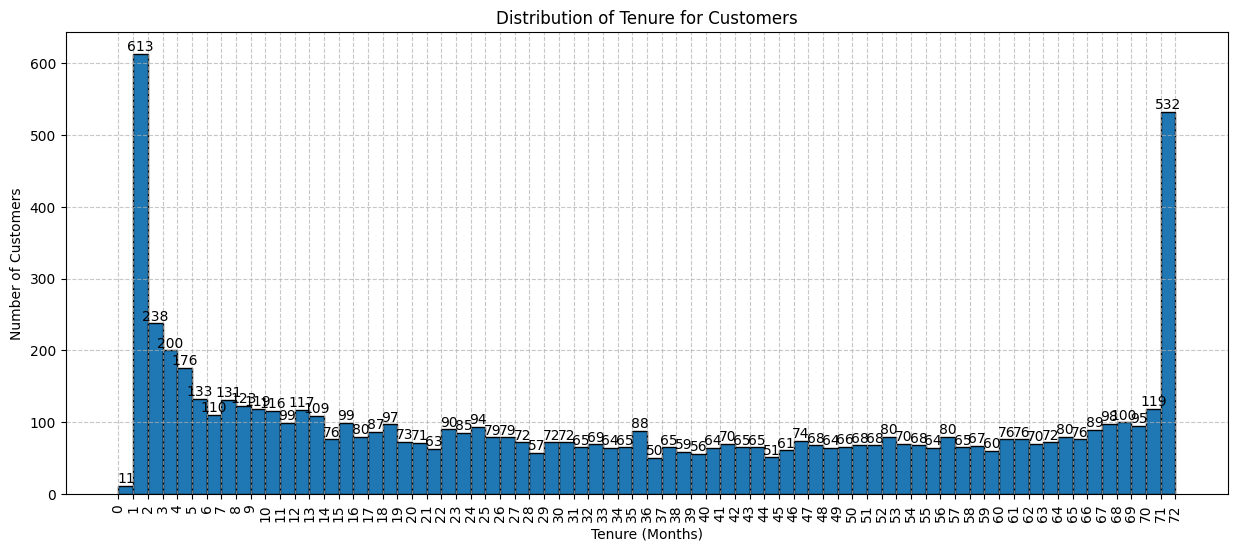

In [13]:
plt.figure(figsize=(15, 6))
a = plt.hist(x=df['tenure'], bins=72, edgecolor= 'black')
plt.title('Distribution of Tenure for Customers')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.bar_label(a[2])
plt.xticks(a[1],rotation=90)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<Axes: xlabel='tenure', ylabel='Density'>

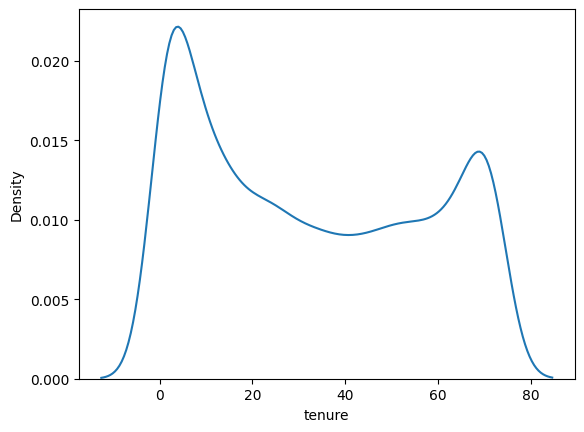

In [14]:
sns.kdeplot(data = df, x='tenure')

In [15]:
df['tenure'].skew()

np.float64(0.2395397495619829)

<Axes: ylabel='tenure'>

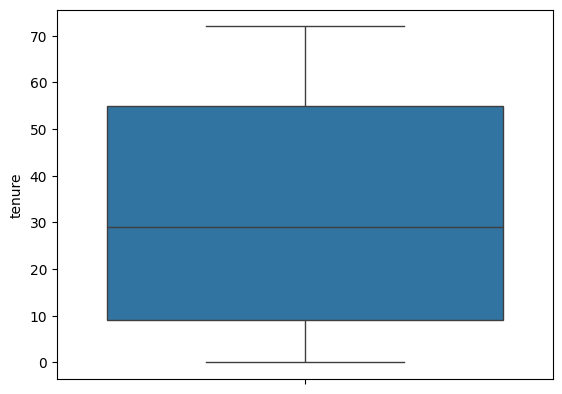

In [16]:
sns.boxplot(data = df ,y = df['tenure'])

**💡 Insight — Tenure is Bimodal (U-Shaped):**
- Two large spikes exist: at **month 1** (brand new, high churn risk) and **month 72** (longest-serving, very loyal).
- Churning is low after **14th month** and slightly increasing after **66th month**.
- Skewness is near zero overall but the bimodal shape hides two very different customer populations inside one dataset.
- **Business implication:** Getting a customer past their first 12 months is the critical survival threshold — after that, loyalty compounds dramatically.


### MonthlyCharges Distribution

Text(0.5, 1.0, 'MonthlyCharges')

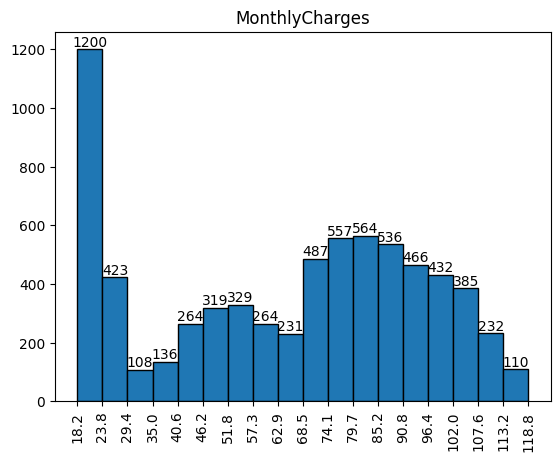

In [17]:
a= plt.hist(x=df['MonthlyCharges'], bins='auto', edgecolor='black')
plt.bar_label(a[2])
plt.xticks(a[1],rotation=90)
plt.title('MonthlyCharges')

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

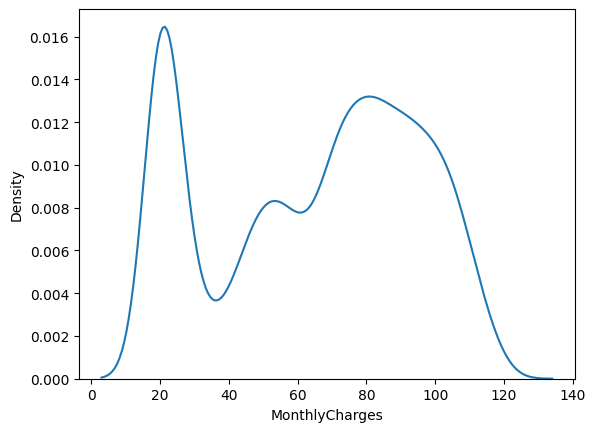

In [18]:
sns.kdeplot(data = df, x='MonthlyCharges')

In [19]:
df['MonthlyCharges'].skew()

np.float64(-0.22052443394398033)

<Axes: >

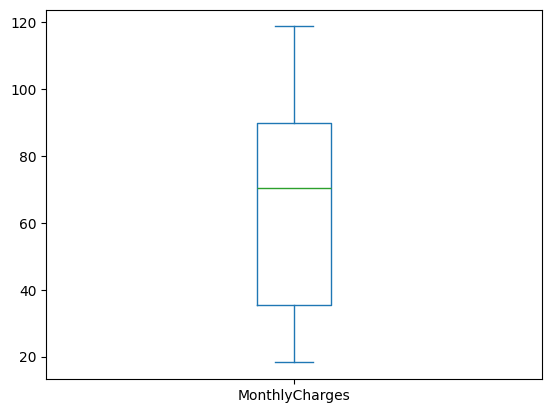

In [20]:
df['MonthlyCharges'].plot(kind='box')

**💡 Insight — MonthlyCharges Has Two Clusters:**
- A sharp spike around **£20** (basic phone-only plans with no internet).
- A broader cluster between **£60–£100** (internet + add-on subscribers).
- Very few customers sit in the £30–£50 range — suggesting distinct product tiers rather than a smooth pricing gradient.
- **Business implication:** The company effectively has two product categories. Churn behaviour is likely very different between these clusters — which the later analysis confirms.


### TotalCharges Distribution

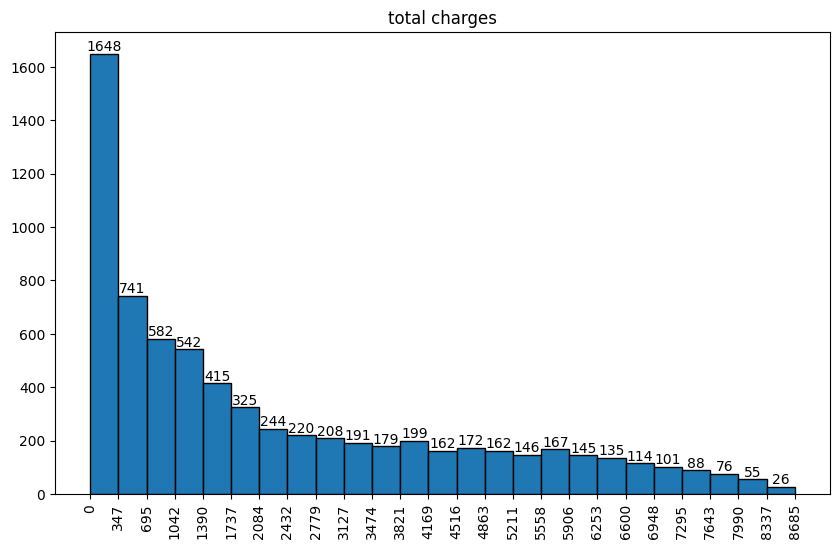

In [21]:
plt.figure(figsize=(10, 6))
a= plt.hist(x=df['TotalCharges'],bins='auto',edgecolor='black')
plt.bar_label(a[2])
plt.xticks(a[1],rotation=90)
plt.title('total charges')
plt.show()


<Axes: ylabel='Density'>

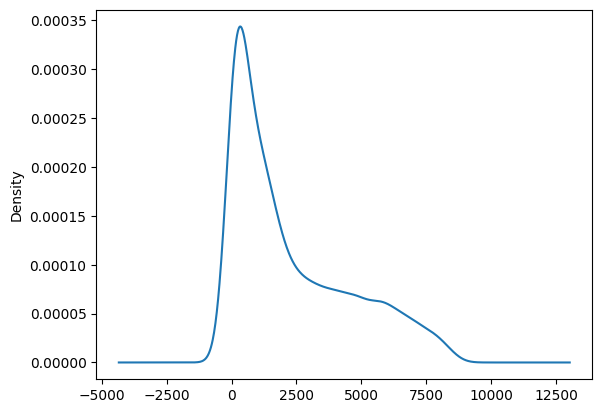

In [22]:
df['TotalCharges'].plot(kind='kde')

In [23]:
df['TotalCharges'].skew()

np.float64(0.963234654832277)

<Axes: >

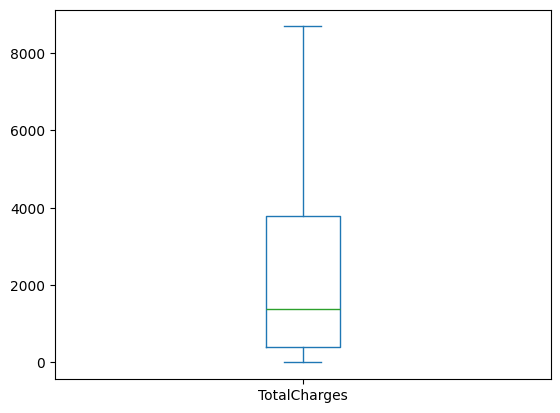

In [24]:
df['TotalCharges'].plot(kind='box')

**💡 Insight — TotalCharges is Heavily Right-Skewed:**
- Most customers have low TotalCharges — they are relatively new to the service.
- A small group of long-tenure customers have accumulated £5,000–£8,000+ in lifetime spend.
- TotalCharges is largely `tenure × MonthlyCharges` — it carries overlapping information and **should not be used alongside tenure as an independent feature**.
- It is most useful for identifying high-LTV customers worth prioritising in retention campaigns.


# 5. 🎯 Churn Overview

[Text(0, 0, '5174'), Text(0, 0, '1869')]

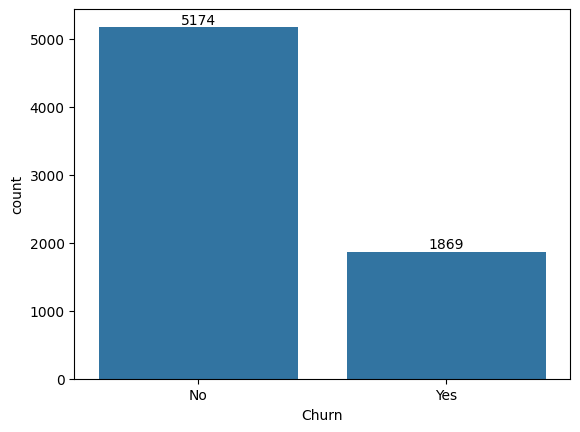

In [25]:
a = sns.countplot(data=df, x='Churn')
a.bar_label(a.containers[0])

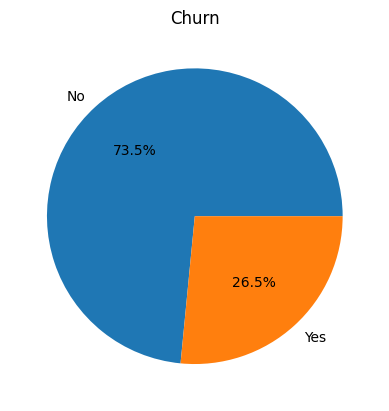

In [26]:
plt.pie(df['Churn'].value_counts(), labels=df['Churn'].value_counts().index, autopct='%1.1f%%')
plt.title('Churn')
plt.show()

**💡 Insight — Overall Churn Rate is 26.5%:**
- **1,869 out of 7,043 customers have churned** — roughly 1 in 4.
- Telecom industry benchmark churn is typically 15–25% annually. This company is at the higher end.
- **All subsequent churn rates should be compared against this 26.5% baseline** — anything above is above average risk, anything below is a relatively stable group.


# 6. 👥 Churn by Demographics

### Gender & Senior Citizen

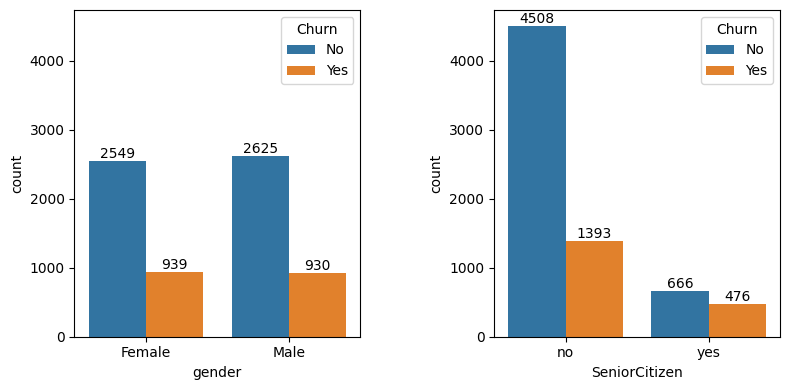

In [27]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 2, 1)
a = sns.countplot(data=df, x='gender',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax2 = fig.add_subplot(1, 2, 2, sharey= ax1)
a = sns.countplot(data=df, x='SeniorCitizen',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

plt.tight_layout(w_pad=5)
plt.show()

**💡 Insights:**
- **Gender has virtually no impact on churn** — male and female rates are nearly identical (~26%). Gender should be completely deprioritised in retention strategy.
- **Senior citizens churn significantly more (~41%)** vs non-seniors (~24%). Seniors are ~16% of the customer base but represent a disproportionately at-risk group.


### Partner & Dependents

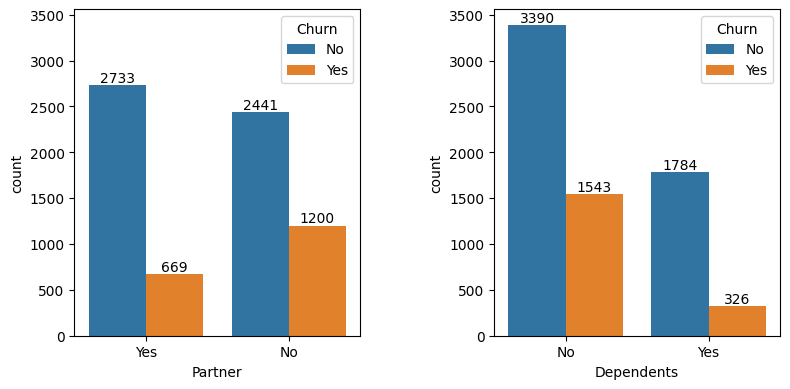

In [28]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 2, 1)
a = sns.countplot(data=df, x='Partner',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax2 = fig.add_subplot(1, 2, 2, sharey= ax1)
a = sns.countplot(data=df, x='Dependents',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

plt.tight_layout(w_pad=5)
plt.show()



**💡 Insights:**
- **Customers without a partner churn more (~33% vs ~20%)** — solo customers have less household inertia keeping them subscribed.
- **Customers without dependents churn more (~31% vs ~17%)** — families with children tend to be more stable, long-term subscribers.
- Together, these suggest **household size and stability** are stronger predictors than demographics like gender or age alone.


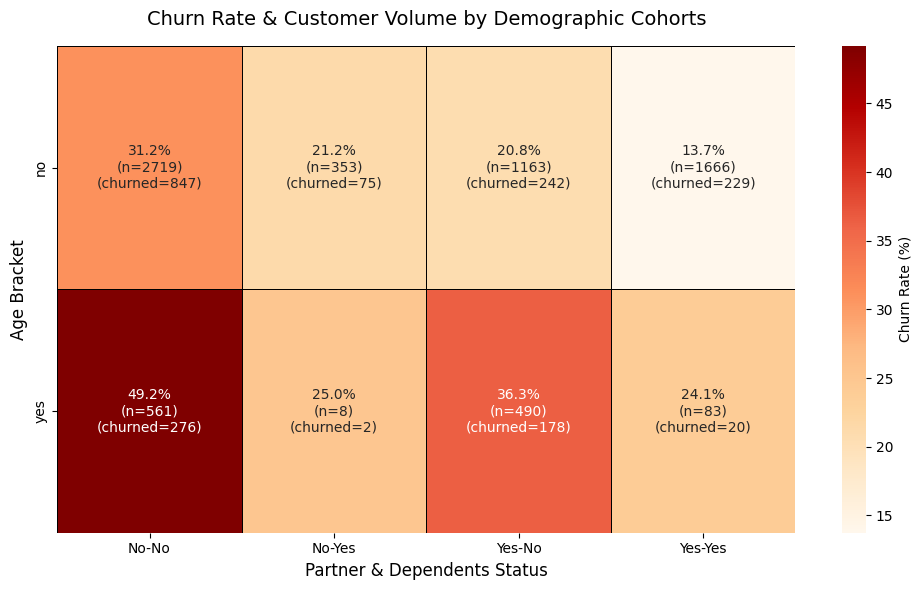

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert Churn to 1/0 so we can calculate the mean (which equals the churn rate)
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Create a multi-level pivot table for Churn Rate
churn_rate_matrix = df.pivot_table(
    values='Churn_Numeric',
    index='SeniorCitizen',
    columns=['Partner', 'Dependents'],
    aggfunc='mean'
) * 100 # Multiply by 100 to make it a percentage

# 3. Create a multi-level pivot table for Customer Count
churn_count_matrix = df.pivot_table(
    values='Churn_Numeric',
    index='SeniorCitizen',
    columns=['Partner', 'Dependents'],
    aggfunc='count'
).fillna(0) # Fill NaN with 0 for combinations with no customers

# 4. Create a custom annotation matrix
custom_annotations = np.empty_like(churn_rate_matrix, dtype=object)

for i in range(churn_rate_matrix.shape[0]):
    for j in range(churn_rate_matrix.shape[1]):
        rate = churn_rate_matrix.iloc[i, j]
        total_count = int(churn_count_matrix.iloc[i, j])

        if pd.isna(rate) or total_count == 0:
            custom_annotations[i, j] = "N/A\n(n=0)"
        else:
            churned_count = round(total_count * (rate / 100))
            custom_annotations[i, j] = f"{rate:.1f}%\n(n={total_count})\n(churned={int(churned_count)})"

# 5. Plot the Heatmap with custom annotations
plt.figure(figsize=(10, 6))
sns.heatmap(
    churn_rate_matrix, # Color the heatmap based on the churn rate
    annot=custom_annotations, # Use the custom text for annotations
    fmt='', # Set fmt to empty string so Seaborn doesn't format our custom text
    cmap='OrRd',        # Orange-Red color scale (Red = High Churn Risk)
    cbar_kws={'label': 'Churn Rate (%)'},
    linewidths=0.5, # Add lines between cells for better readability
    linecolor='black'
)

plt.title('Churn Rate & Customer Volume by Demographic Cohorts', fontsize=14, pad=15)
plt.xlabel('Partner & Dependents Status', fontsize=12)
plt.ylabel('Age Bracket', fontsize=12)
plt.tight_layout()
plt.show()

**💡 Insight — The Highest-Risk Demographic Cohort Identified:**
- The heatmap reveals the exact churn rate for every combination of Senior × Partner × Dependents.
- **Senior + No Partner + No Dependents** is the darkest cell — the single highest churn rate in all demographic combinations.
- **Non-Senior + Has Partner + Has Dependents** is the lightest — families with full household stability.
- **Business implication:** The company can now build a precise demographic risk score. A Senior without a partner or dependents should trigger an automatic outreach campaign.


# 7. 📞 Churn by Phone Services

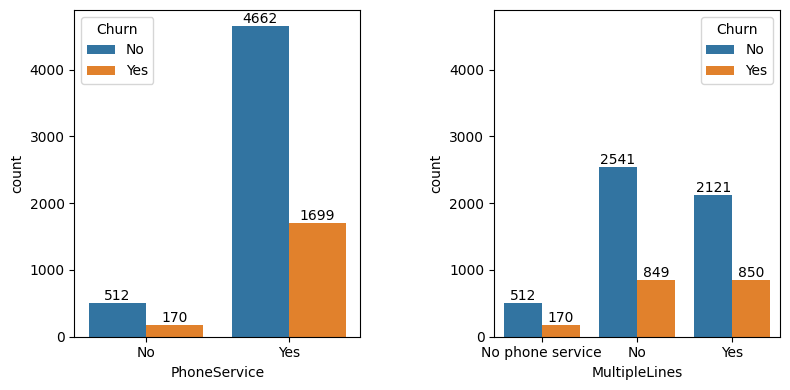

In [31]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 2, 1)
a = sns.countplot(data=df, x='PhoneService',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax2 = fig.add_subplot(1, 2, 2, sharey= ax1)
a = sns.countplot(data=df, x='MultipleLines',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

plt.tight_layout(w_pad=5)
plt.show()

### Phone_Setup Feature Engineering
Instead of keeping two separate columns (PhoneService + MultipleLines), we created a single **`Phone_Setup`** feature that consolidates both into one clean variable. This is an original feature engineering step that simplifies analysis and reduces redundancy.


  PhoneService     MultipleLines       Phone_Setup
0           No  No phone service  No Phone Service
1          Yes                No       Single Line
2          Yes                No       Single Line
3           No  No phone service  No Phone Service
4          Yes                No       Single Line


/tmp/ipykernel_4460/2246214111.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


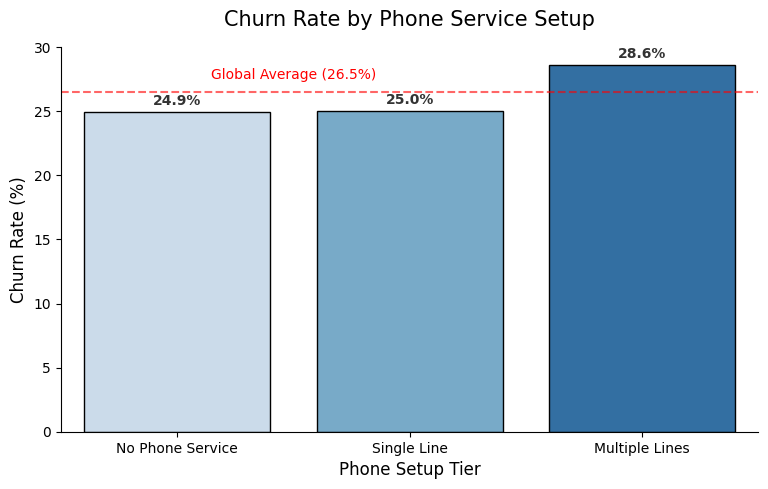

In [32]:
# 1. The Consolidation Function
def get_phone_setup(row):

    if row['PhoneService'] == 'No':
        return 'No Phone Service'
    elif row['MultipleLines'] == 'Yes':
        return 'Multiple Lines'
    else:
        return 'Single Line'

# Apply the function to create our new feature
df['Phone_Setup'] = df.apply(get_phone_setup, axis=1)

print(df[['PhoneService', 'MultipleLines', 'Phone_Setup']].head())

# Calculate the churn rate per setup
setup_churn = df.groupby('Phone_Setup')['Churn_Numeric'].mean() * 100

# Sort the values so the chart tells a clear escalating story
setup_churn = setup_churn.sort_values()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=setup_churn.index,
    y=setup_churn.values,
    palette='Blues',
    edgecolor='black'
)

# Add the percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, weight='bold', color='#333333')

# Professional Styling
plt.title('Churn Rate by Phone Service Setup', fontsize=15, pad=15)
plt.xlabel('Phone Setup Tier', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

# Add a horizontal line for the baseline global churn rate (~26%)
global_churn = df['Churn_Numeric'].mean() * 100
plt.axhline(global_churn, color='red', linestyle='--', alpha=0.6)
plt.text(0.5, global_churn + 1, f'Global Average ({global_churn:.1f}%)', color='red', ha='center')

sns.despine()
plt.show()

**💡 Insight — Phone Service Has Almost No Churn Impact:**
- All three phone setups (No Phone, Single Line, Multiple Lines) have churn rates very close to the 26.5% global average.
- Phone service type is **not a meaningful differentiator** for churn — regardless of what phone plan someone has, their churn probability barely changes.
- **Business implication:** Do not invest retention budget based on phone service type. The real churn drivers lie in internet service and contract type, not phone setup.


# 8. 🌐 Churn by Internet Services

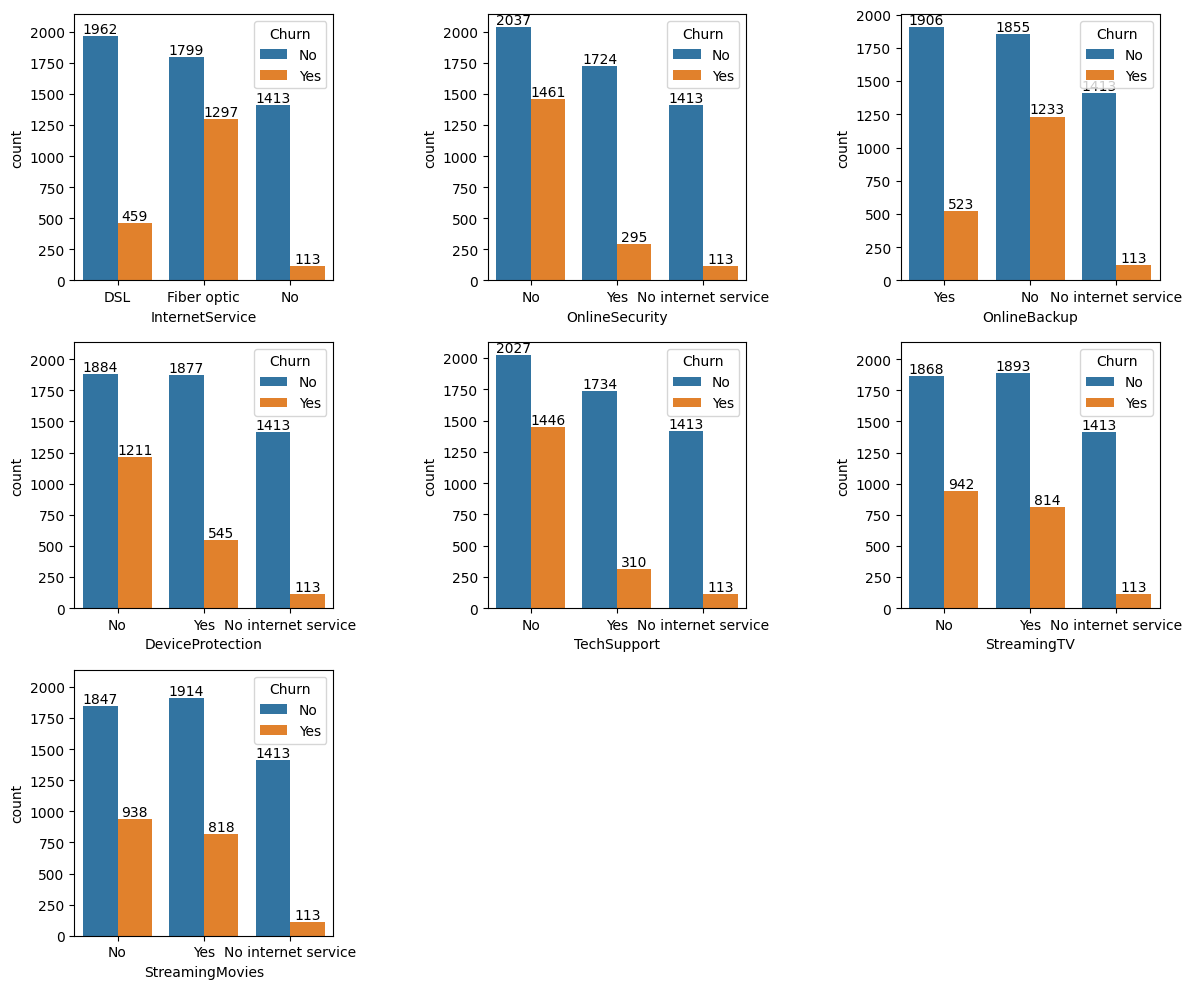

In [33]:
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(3, 3, 1)
a = sns.countplot(data=df, x='InternetService',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax2 = fig.add_subplot(3, 3, 2, sharey= ax1)
a = sns.countplot(data=df, x='OnlineSecurity',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax3 = fig.add_subplot(3, 3, 3)
a = sns.countplot(data=df, x='OnlineBackup',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax4 = fig.add_subplot(3, 3, 4, sharey= ax1)
a = sns.countplot(data=df, x='DeviceProtection',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax5 = fig.add_subplot(3, 3, 5)
a = sns.countplot(data=df, x='TechSupport',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax6 = fig.add_subplot(3, 3, 6, sharey= ax1)
a = sns.countplot(data=df, x='StreamingTV',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax7 = fig.add_subplot(3, 3, 7, sharey= ax1)
a = sns.countplot(data=df, x='StreamingMovies',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

plt.tight_layout(w_pad=5)
plt.show()

**💡 Insights — Internet Add-ons Tell a Clear Story:**
- **No Internet Service customers barely churn (~7%)** — the most stable group in the entire dataset by far.
- **Fiber Optic customers churn at ~42% vs DSL at ~19%** — a massive red flag that demands its own investigation (diagnosed in the Diagnostic section).
- **Every security/utility add-on reduces churn dramatically:** customers *without* OnlineSecurity, TechSupport, OnlineBackup, or DeviceProtection churn at roughly **double the rate** of those who have them.
- **Streaming add-ons (TV/Movies) show near-neutral churn impact** — having or not having them makes very little difference to retention.
- **Pattern:** Security and utility add-ons create dependency and perceived value (customers feel protected). Streaming add-ons are entertainment but don't create switching cost.


### Senior Citizens × Internet Service
An original cross-analysis: do seniors disproportionately use the higher-churn Fiber Optic service? If so, senior churn might be explained by internet type, not age.


[Text(0, 0, '1474'), Text(0, 0, '52')]

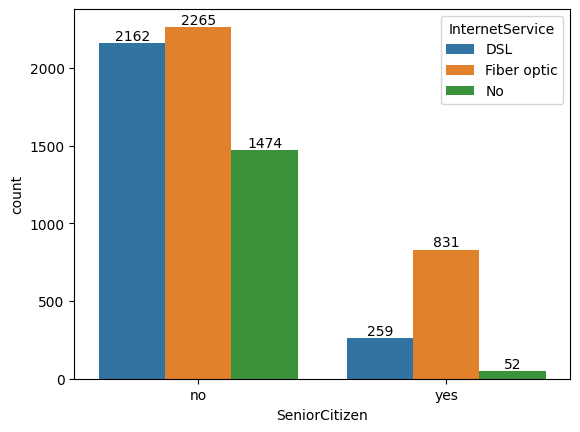

In [34]:
a = sns.countplot(data=df, x='SeniorCitizen',hue='InternetService')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
a.bar_label(a.containers[2])

In [35]:
pd.crosstab(df['SeniorCitizen'],df['InternetService'],normalize='index')

InternetService,DSL,Fiber optic,No
SeniorCitizen,,,
no,0.366379,0.383833,0.249788
yes,0.226795,0.727671,0.045534


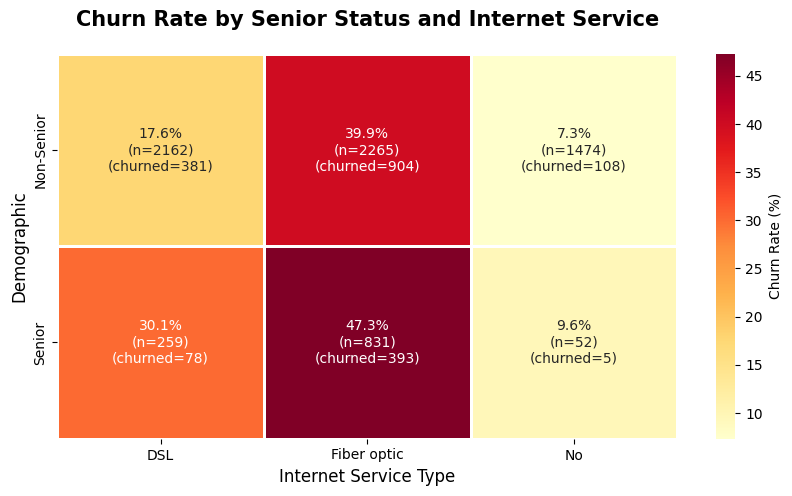

In [73]:
# 1. Clean up SeniorCitizen for readability
df['Senior_Status'] = df['SeniorCitizen'].map({'no': 'Non-Senior', 'yes': 'Senior'})
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Create the pivot table for Mean Churn Rate
senior_internet_rate_matrix = df.pivot_table(
    index='Senior_Status',
    columns='InternetService',
    values='Churn_Numeric',
    aggfunc='mean'
) * 100

# 3. Create the pivot table for Customer Count
senior_internet_count_matrix = df.pivot_table(
    index='Senior_Status',
    columns='InternetService',
    values='Churn_Numeric',
    aggfunc='count'
).fillna(0)

# 4. Create custom annotation matrix
custom_annotations_senior_internet = np.empty_like(senior_internet_rate_matrix, dtype=object)

for i in range(senior_internet_rate_matrix.shape[0]):
    for j in range(senior_internet_rate_matrix.shape[1]):
        rate = senior_internet_rate_matrix.iloc[i, j]
        total_count = int(senior_internet_count_matrix.iloc[i, j])

        if pd.isna(rate) or total_count == 0:
            custom_annotations_senior_internet[i, j] = "N/A\n(n=0)"
        else:
            churned_count = round(total_count * (rate / 100))
            custom_annotations_senior_internet[i, j] = f"{rate:.1f}%\n(n={total_count})\n(churned={int(churned_count)})"

# 5. Plot the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    senior_internet_rate_matrix,
    annot=custom_annotations_senior_internet,
    fmt='',
    cmap='YlOrRd',
    linewidths=1,
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title('Churn Rate by Senior Status and Internet Service', fontsize=15, pad=20, weight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Demographic', fontsize=12)
plt.show()

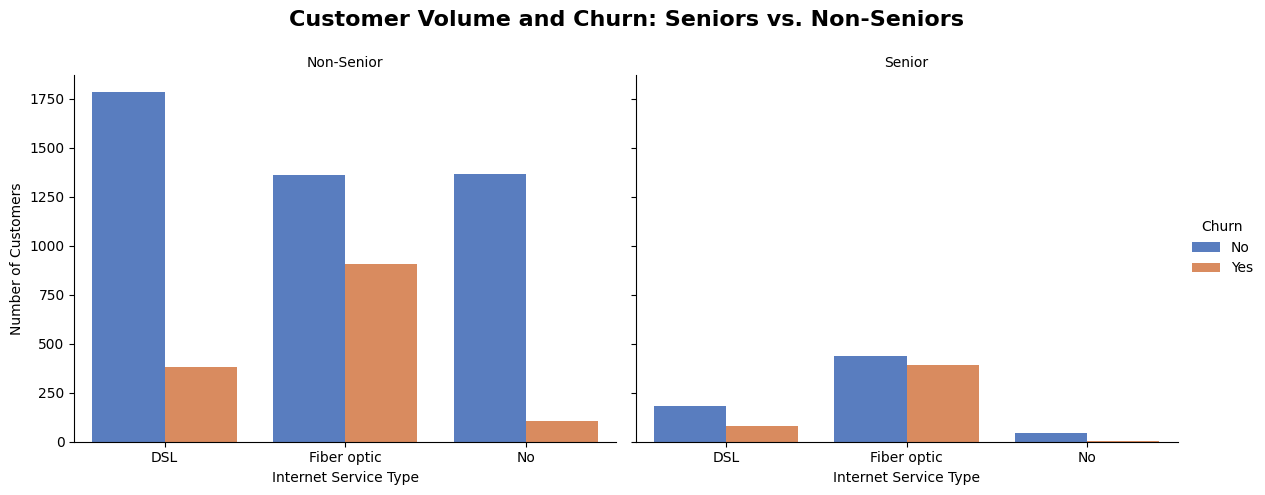

In [37]:
# Create a faceted count plot
g = sns.catplot(
    data=df,
    x='InternetService',
    hue='Churn',
    col='Senior_Status', # Creates side-by-side charts for Seniors vs Non-Seniors
    kind='count',
    palette='muted',
    height=5,
    aspect=1.2
)

g.set_axis_labels("Internet Service Type", "Number of Customers")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Customer Volume and Churn: Seniors vs. Non-Seniors', fontsize=16, weight='bold')
plt.show()

**💡 Insight — Senior Churn Is Partly Explained by Internet Service:**
- The heatmap confirms: **Senior + Fiber Optic** is the highest churn rate combination across all demographic-service pairs.
- Seniors are disproportionately on Fiber Optic relative to their share of the customer base.
- This means **senior churn is not purely an age effect** — it's compounded by the fact that seniors tend to use the higher-risk internet service.
- **Business implication:** A senior-specific Fiber Optic bundle with built-in TechSupport would directly address both the demographic and service risk simultaneously.


[Text(0, 0, '58.1022'), Text(0, 0, '91.5001'), Text(0, 0, '21.0792')]

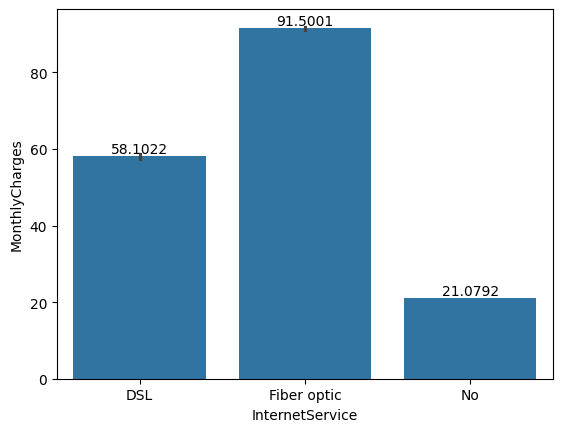

In [38]:
a=sns.barplot(data=df, x='InternetService',y='MonthlyCharges', estimator='mean')
a.bar_label(a.containers[0])

**💡 Insight:** Fiber Optic customers pay significantly higher monthly charges than DSL customers. This price gap, combined with fewer add-ons (shown in the diagnostic section), creates a perceived value problem that drives churn.


### Internet Persona Feature Engineering
An original feature that classifies every internet customer into one of four personas based on their add-on combination. This goes well beyond simple column analysis — it reveals *types* of customers, not just individual feature effects.


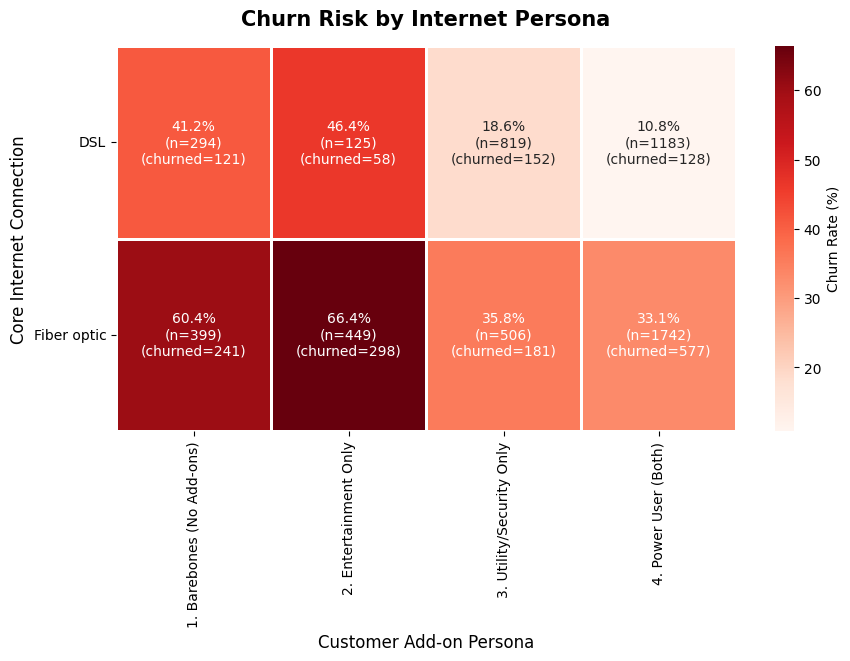

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the transformation function
def build_internet_persona(row):
    # If they don't have internet, they get a blank persona
    if row['InternetService'] == 'No':
        return 'No Internet'

    # Check if they have ANY security/utility add-ons
    has_security = (row['OnlineSecurity'] == 'Yes' or
                    row['TechSupport'] == 'Yes' or
                    row['OnlineBackup'] == 'Yes' or
                    row['DeviceProtection'] == 'Yes')

    # Check if they have ANY media add-ons
    has_media = (row['StreamingTV'] == 'Yes' or
                 row['StreamingMovies'] == 'Yes')

    # Assign the Persona
    if has_security and has_media:
        return '4. Power User (Both)'
    elif has_security:
        return '3. Utility/Security Only'
    elif has_media:
        return '2. Entertainment Only'
    else:
        return '1. Barebones (No Add-ons)'

# 2. Apply the function to create our single new column
df['Internet_Persona'] = df.apply(build_internet_persona, axis=1)

# Ensure Churn is numeric
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 1. Filter out the 'No Internet' group to keep the heatmap focused on active users
df_active_internet = df[df['InternetService'] != 'No']

# 2. Calculate the Churn Rate Matrix
persona_matrix = df_active_internet.pivot_table(
    values='Churn_Numeric',
    index='InternetService',
    columns='Internet_Persona',
    aggfunc='mean'
) * 100

# 3. Create the pivot table for Customer Count
persona_count_matrix = df_active_internet.pivot_table(
    values='Churn_Numeric',
    index='InternetService',
    columns='Internet_Persona',
    aggfunc='count'
).fillna(0)

# 4. Create custom annotation matrix
custom_annotations_persona_internet = np.empty_like(persona_matrix, dtype=object)

for i in range(persona_matrix.shape[0]):
    for j in range(persona_matrix.shape[1]):
        rate = persona_matrix.iloc[i, j]
        total_count = int(persona_count_matrix.iloc[i, j])

        if pd.isna(rate) or total_count == 0:
            custom_annotations_persona_internet[i, j] = "N/A\n(n=0)"
        else:
            churned_count = round(total_count * (rate / 100))
            custom_annotations_persona_internet[i, j] = f"{rate:.1f}%\n(n={total_count})\n(churned={int(churned_count)})"


# 5. Plot the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    persona_matrix,
    annot=custom_annotations_persona_internet,
    fmt='', # Set fmt to empty string so Seaborn doesn't format our custom text
    cmap='Reds', # Red instantly highlights the danger zones
    linewidths=1,
    cbar_kws={'label': 'Churn Rate (%)'}
)

# 6. Professional Styling
plt.title('Churn Risk by Internet Persona', fontsize=15, pad=15, weight='bold')
plt.xlabel('Customer Add-on Persona', fontsize=12)
plt.ylabel('Core Internet Connection', fontsize=12)
plt.yticks(rotation=0)

plt.show()

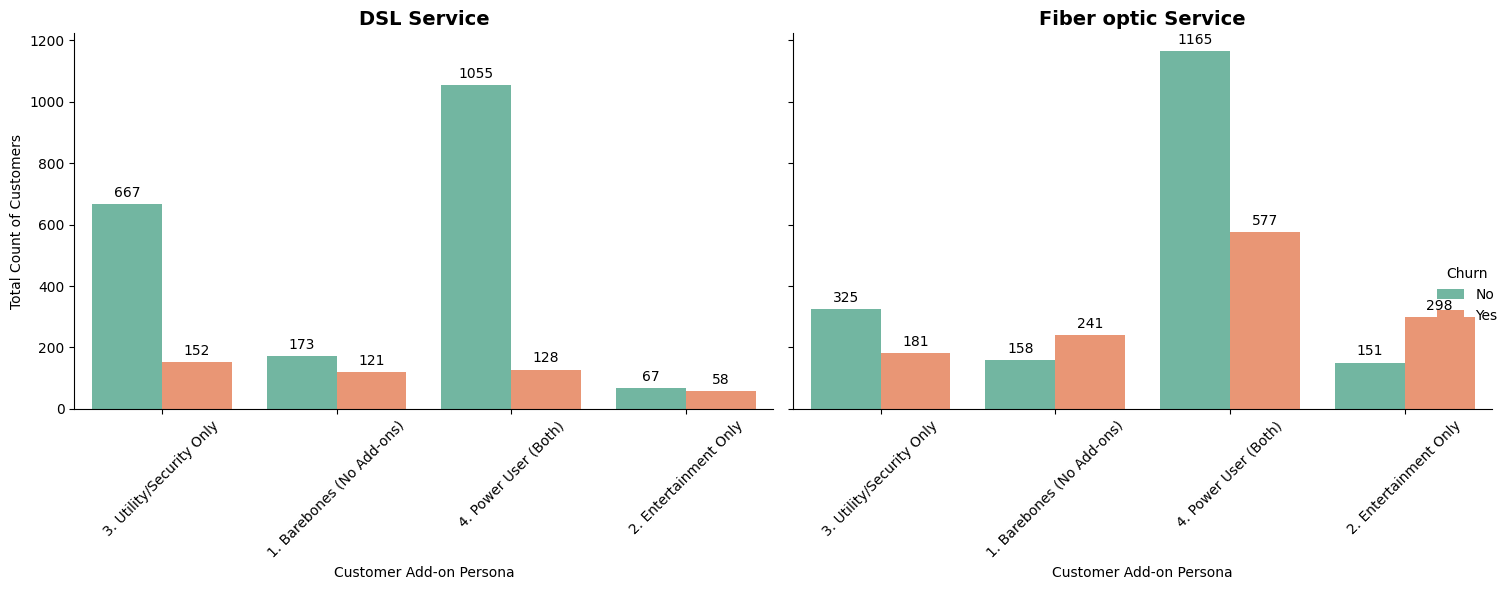

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# (Assuming 'df_active_internet' from your previous code is already loaded)

# 1. Create the Faceted Count Plot
# 'col' splits the data into separate charts based on Internet Service
g = sns.catplot(
    data=df_active_internet,
    x='Internet_Persona',
    hue='Churn',           # Splits the bars by Yes/No
    col='InternetService', # Creates side-by-side charts for DSL and Fiber
    kind='count',          # Tells Seaborn we want to count the rows
    palette='Set2',
    height=6,              # Height of each individual chart
    aspect=1.2             # Makes each chart slightly wider
)

# 2. Make the titles and labels professional
g.set_axis_labels("Customer Add-on Persona", "Total Count of Customers")
g.set_titles("{col_name} Service", size=14, weight='bold') # Dynamic title for each chart

# 3. Add exact counts on top of bars and rotate text
# We loop through both the DSL chart and Fiber Optic chart to format them
for ax in g.axes.flat:
    # Rotate the long Persona names so they don't overlap
    ax.tick_params(axis='x', labelrotation=45)

    # Grab the bars and attach the exact count number on top
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%.0f', color='black')

# Adjust layout so the rotated text isn't cut off
plt.tight_layout()
plt.show()

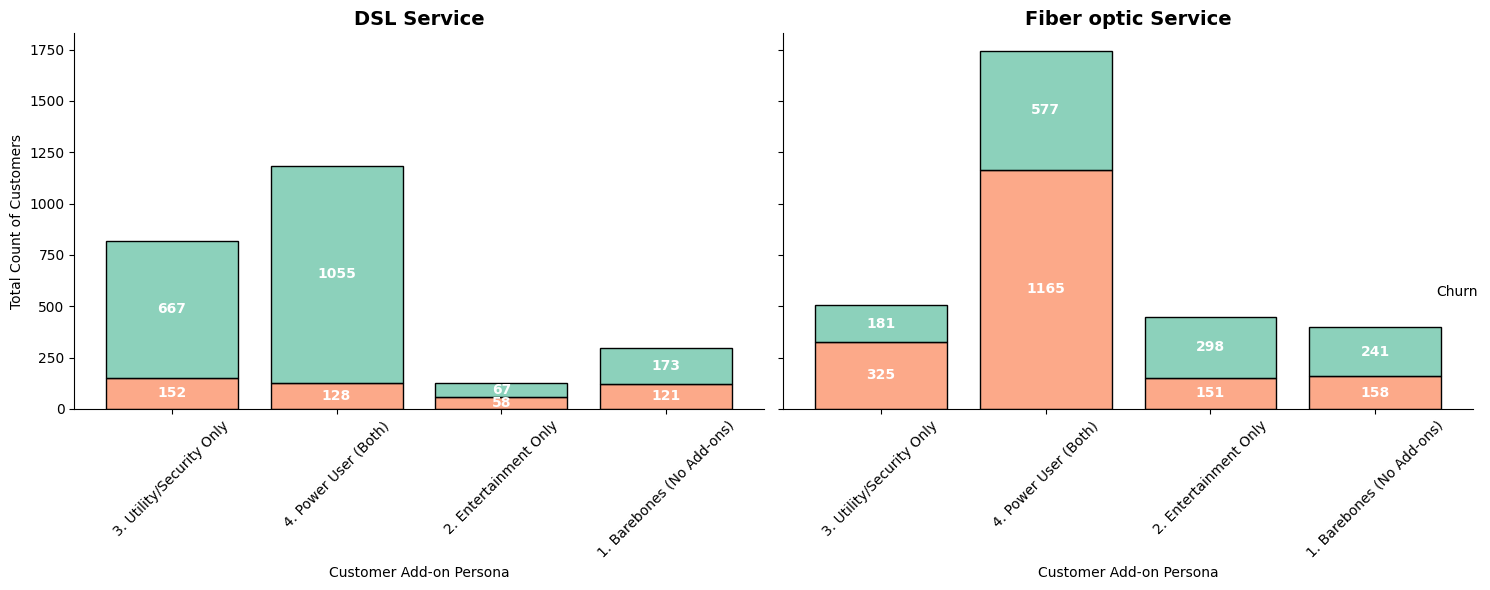

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the blank grid, splitting by InternetService (exactly like catplot did)
g = sns.FacetGrid(df_active_internet, col='InternetService', height=6, aspect=1.2)

# 2. Map a stacked histplot onto the grid
g.map_dataframe(
    sns.histplot,
    x='Internet_Persona',
    hue='Churn',
    multiple='stack', # The magic word for stacking
    shrink=0.8,       # Adds space between bars so they don't touch like a normal histogram
    palette='Set2'
)

# 3. Clean up the titles and labels
g.set_axis_labels("Customer Add-on Persona", "Total Count of Customers")
g.set_titles("{col_name} Service", size=14, weight='bold')
g.add_legend(title='Churn') # Fix: Add the legend and set its title using add_legend

# 4. Add the exact counts INSIDE the stacked sections
for ax in g.axes.flat:
    # Rotate the long Persona names so they don't overlap
    ax.tick_params(axis='x', labelrotation=45)

    # Grab the bars and attach the count
    for container in ax.containers:
        # label_type='center' is crucial here! It puts the number inside the block
        # instead of stacking them all on the very top edge.
        ax.bar_label(container, fmt='%.0f', label_type='center', color='white', weight='bold')

# Adjust layout so the rotated text isn't cut off

plt.tight_layout()
plt.show()

**💡 Insight — The Barebones Customer Is the Highest Churn Risk:**
- **Fiber Optic Barebones (no add-ons at all)** is the single highest-risk persona — churning at dramatically above-average rates.
- **Adding Entertainment** only increases churn rates in both DSL and Fibre by a slight margin.
- **Power Users (both security + entertainment add-ons)** churn the least — they are most embedded in the product ecosystem and have the highest switching cost.
- The trend is consistent across both DSL and Fiber: more add-ons = lower churn, regardless of the internet type.
- **Business implication:** The persona framework gives the CRM team a simple segmentation tool. Identify all Barebones customers and launch a targeted add-on trial campaign immediately.


### Product Co-occurrence — Which Add-ons Are Bought Together?

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   StreamingMovies  
0                0  
1                0  
2                0  
3                0  
4                0  


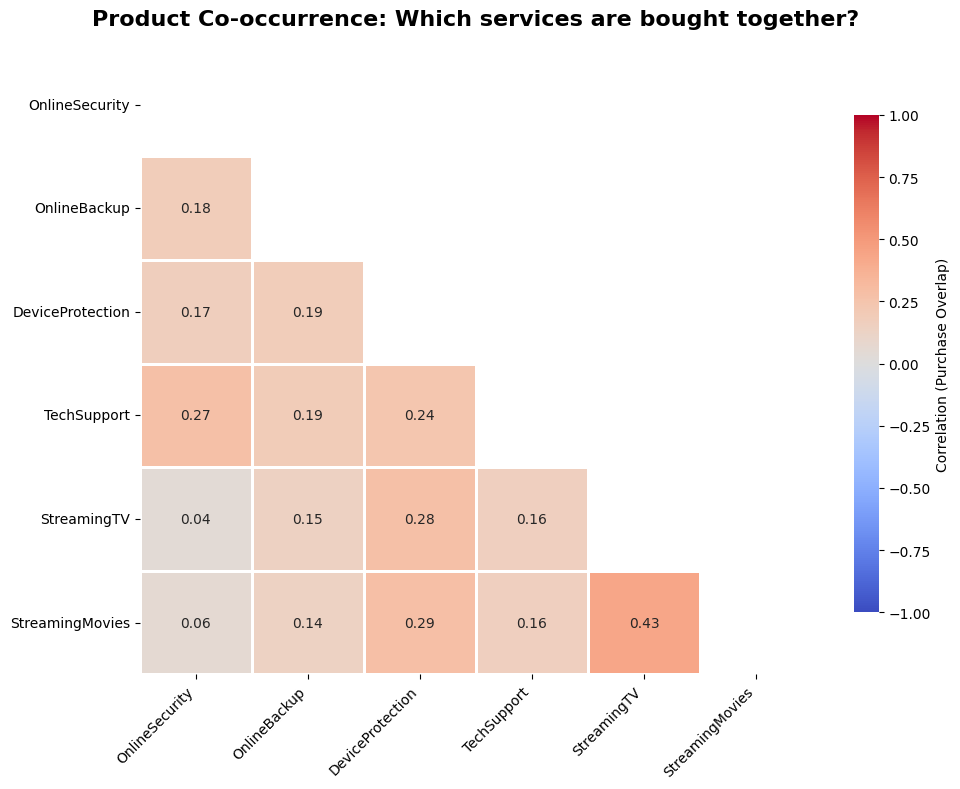

In [75]:
# 1. Define the add-on columns
add_ons = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies']

# 2. THE FILTER: Isolate only active internet users
df_active = df[df['InternetService'] != 'No'].copy()

# 3. THE BINARIZE STEP: Convert 'Yes' to 1, 'No' to 0
# This allows us to run mathematical correlation on text columns
for col in add_ons:
    df_active[col] = df_active[col].map({'Yes': 1, 'No': 0})

print(df_active[add_ons].head())

# 1. Calculate the correlation matrix
correlation_matrix = df_active[add_ons].corr()

# 2. Mask the upper triangle (Optional but highly recommended)
# A correlation matrix is a mirror image of itself. Masking the top half
# removes redundant data and makes it look incredibly clean and professional.
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 3. Plot the Matrix
plt.figure(figsize=(10, 8))

# We use 'coolwarm' so that strong pairings turn dark red, and negative pairings turn blue
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1, # Anchors the colors properly
    linewidths=1,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation (Purchase Overlap)'}
)

plt.title('Product Co-occurrence: Which services are bought together?', fontsize=16, pad=20, weight='bold')

# Rotate the x-axis labels so they are readable
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**💡 Insight — Security Add-ons Are Bought as a Bundle; Streaming Is Independent:**
- StreamingTV and StreamingMovies are correlated with each other but **weakly correlated with security add-ons** — they represent a separate buying decision.
- **Everything** else is weakly correlated
- **Business implication:** Bundle security add-ons together in the product catalogue — they're naturally purchased as a group. Don't assume streaming subscribers will cross-buy security services; target them with a separate security upsell campaign.


### The 128-Cohort Service Combination Matrix

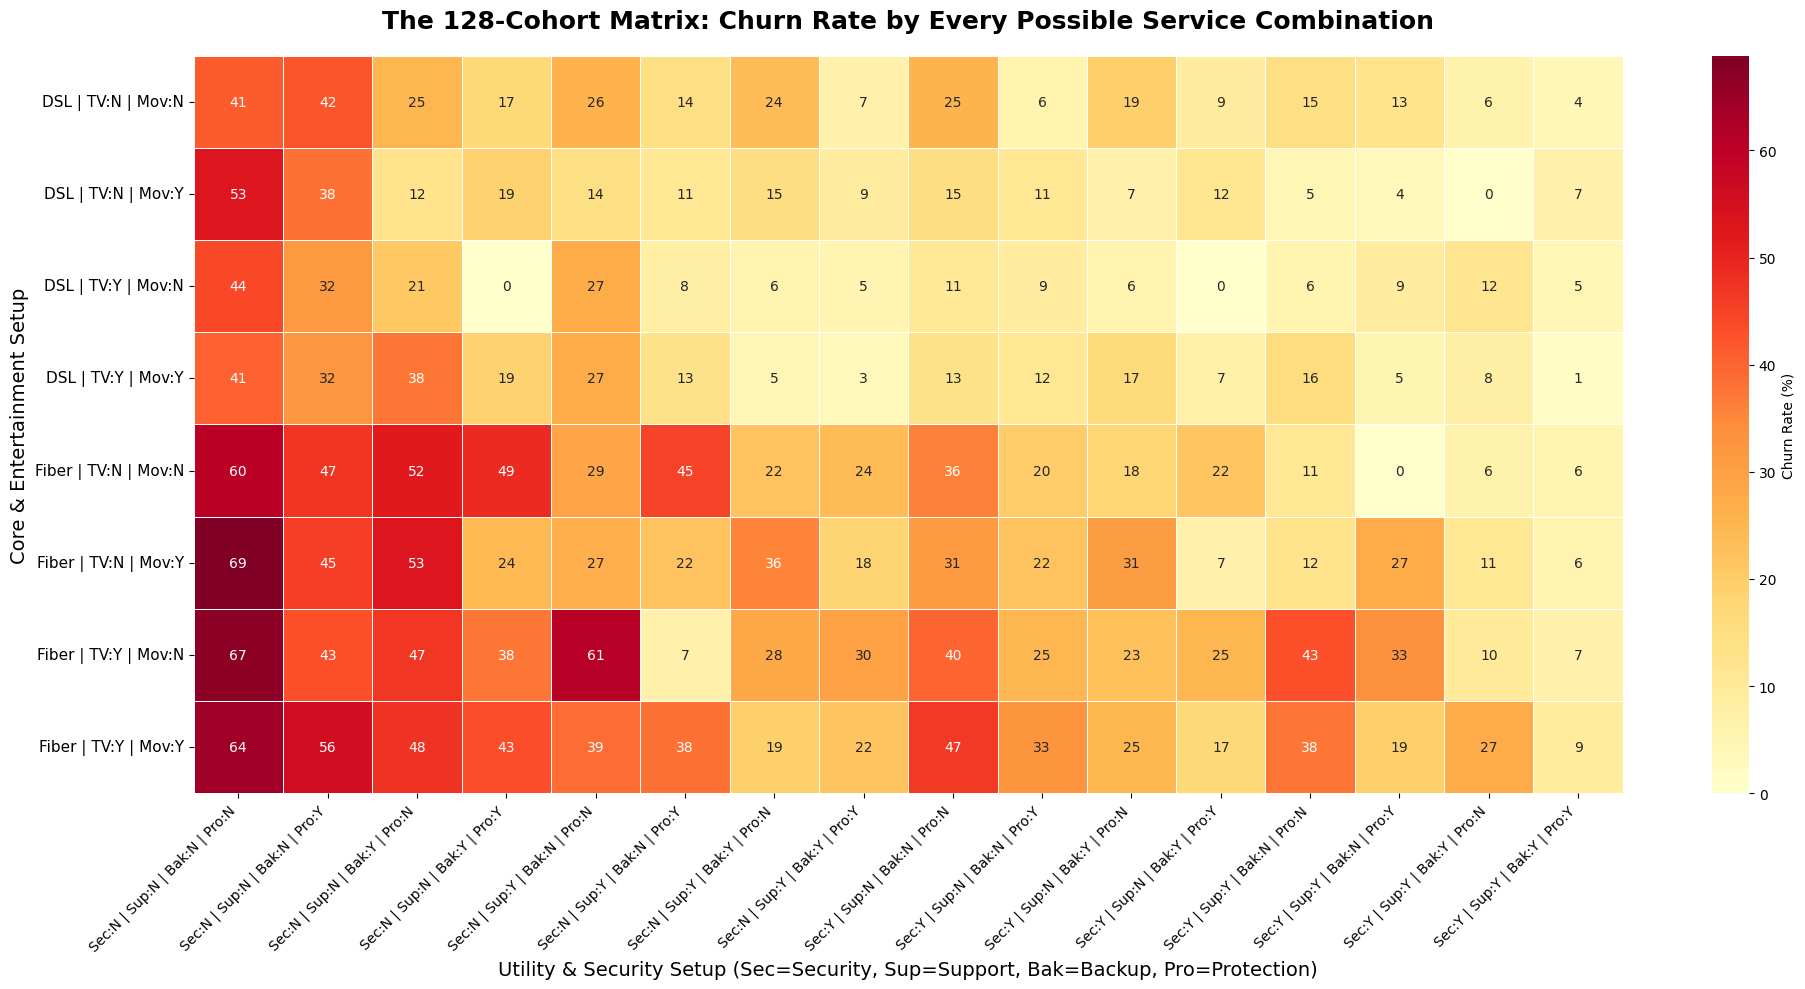

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define our columns
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# 2. Filter to Active Internet Users Only
df_active = df[df['InternetService'] != 'No'].copy()
df_active['Churn_Numeric'] = df_active['Churn'].map({'Yes': 1, 'No': 0})

# 3. Create the Y-Axis Labels (Core + Entertainment = 8 combinations)
# We use a lambda function to compress the Yes/No responses into a clean, readable string
df_active['Y_Group'] = df_active.apply(
    lambda x: f"{x['InternetService'][:5]} | TV:{x['StreamingTV'][0]} | Mov:{x['StreamingMovies'][0]}",
    axis=1
)

# 4. Create the X-Axis Labels (Security + Utility = 16 combinations)
df_active['X_Group'] = df_active.apply(
    lambda x: f"Sec:{x['OnlineSecurity'][0]} | Sup:{x['TechSupport'][0]} | Bak:{x['OnlineBackup'][0]} | Pro:{x['DeviceProtection'][0]}",
    axis=1
)

# 5. Calculate the Churn Rate for all 128 combinations
mega_matrix = df_active.pivot_table(
    index='Y_Group',
    columns='X_Group',
    values='Churn_Numeric',
    aggfunc='mean'
) * 100

# 6. Plot the 128-Cell Mega Matrix
plt.figure(figsize=(20, 10)) # Needs to be very wide to fit 16 columns

sns.heatmap(
    mega_matrix,
    annot=True,         # Shows the exact percentage in every single cell
    fmt='.0f',          # Round to whole numbers to save space (e.g., '45' instead of '45.2')
    cmap='YlOrRd',      # Yellow to Red
    linewidths=0.5,
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title('The 128-Cohort Matrix: Churn Rate by Every Possible Service Combination', fontsize=18, pad=20, weight='bold')
plt.xlabel('Utility & Security Setup (Sec=Security, Sup=Support, Bak=Backup, Pro=Protection)', fontsize=14)
plt.ylabel('Core & Entertainment Setup', fontsize=14)

# Rotate X labels slightly so all 16 fit cleanly
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

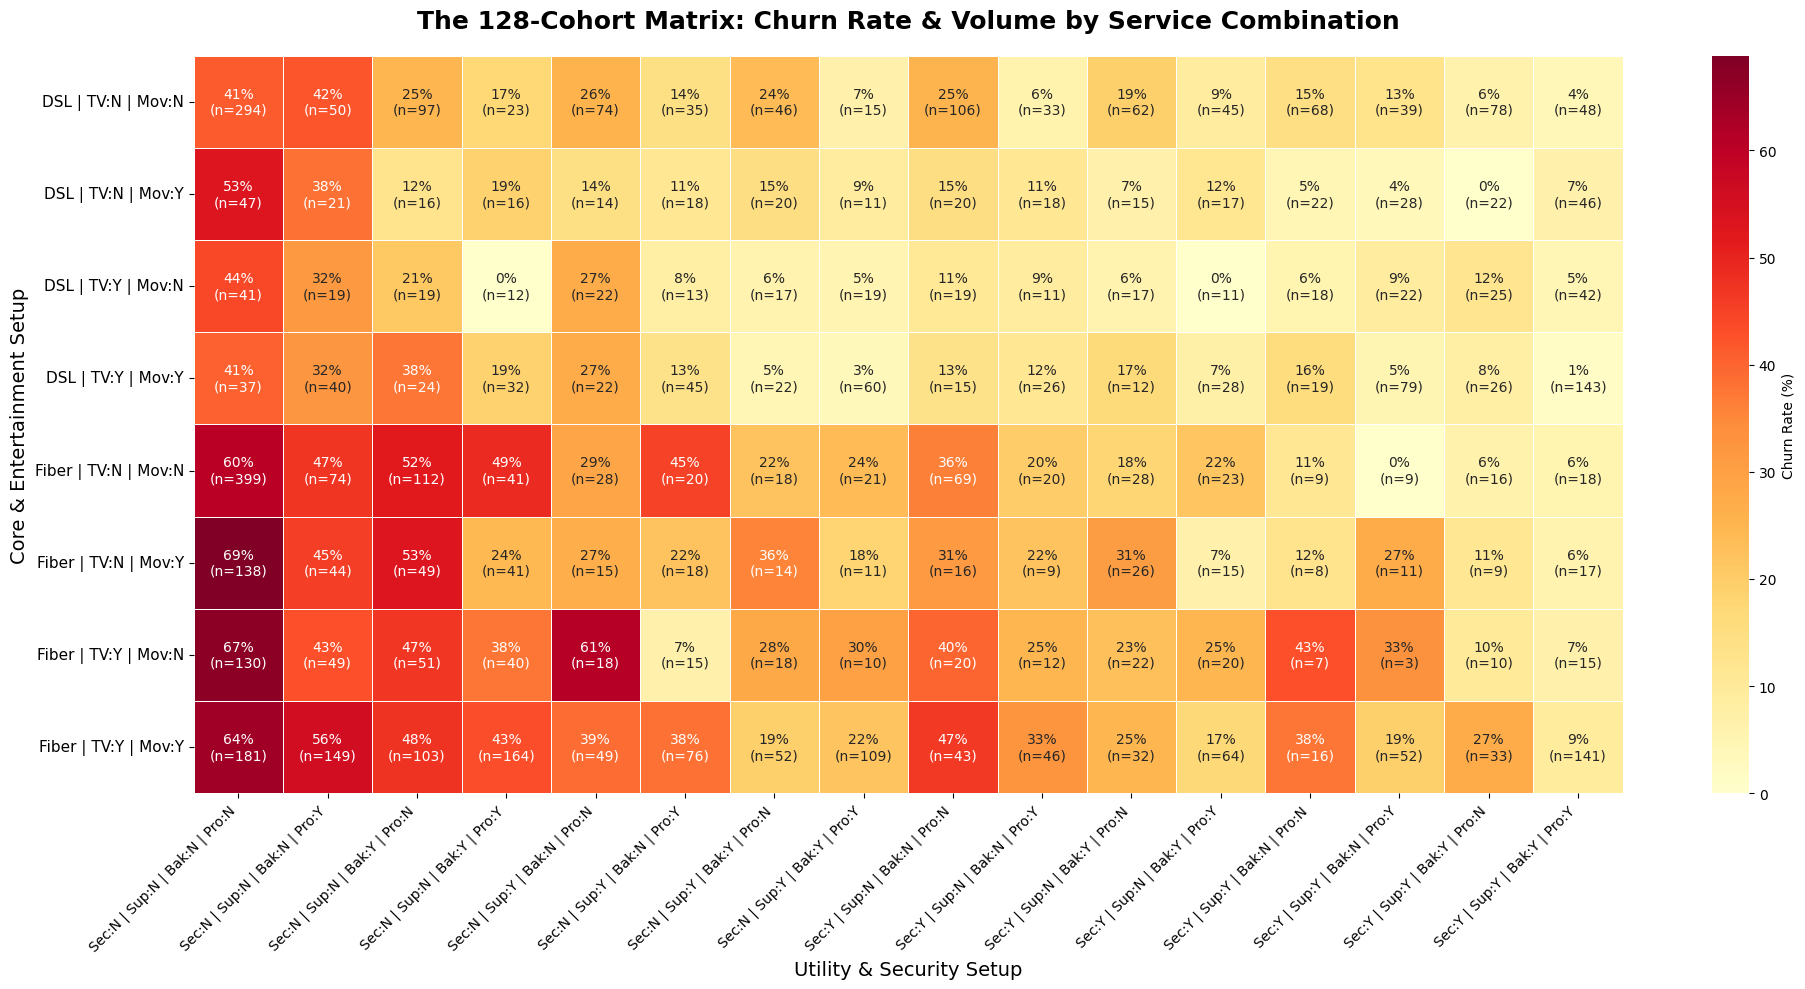

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# (Assuming df_active, Y_Group, and X_Group are already created from the previous step)

# 1. Calculate the Churn Rate Matrix (Percentage)
matrix_rate = df_active.pivot_table(
    index='Y_Group',
    columns='X_Group',
    values='Churn_Numeric',
    aggfunc='mean'
) * 100

# 2. Calculate the Total Volume Matrix (Count)
# We use aggfunc='count' to count how many people are in each cell.
# We also use .fillna(0) because some of the 128 combinations might not exist in the data at all!
matrix_count = df_active.pivot_table(
    index='Y_Group',
    columns='X_Group',
    values='Churn_Numeric',
    aggfunc='count'
).fillna(0)

# 3. THE MAGIC TRICK: Build a custom Text Matrix
# We create an empty grid the exact same size as our heatmap
custom_annotations = np.empty_like(matrix_rate, dtype=object)

# Loop through every row and column to combine the Rate and Count into a single string
for i in range(matrix_rate.shape[0]):
    for j in range(matrix_rate.shape[1]):
        rate = matrix_rate.iloc[i, j]
        count = int(matrix_count.iloc[i, j])

        # If the cell is empty (NaN), label it as N/A
        if pd.isna(rate):
            custom_annotations[i, j] = "N/A\n(n=0)"
        else:
            # Format: "45%\n(n=150)" - The \n forces the count to sit below the percentage
            custom_annotations[i, j] = f"{rate:.0f}%\n(n={count})"

# 4. Plot the Matrix
plt.figure(figsize=(20, 10))

sns.heatmap(
    matrix_rate, # We still color the heatmap based on the Churn RATE
    annot=custom_annotations, # Pass our custom text grid here
    fmt="", # CRITICAL: You must set fmt to an empty string so Seaborn doesn't try to format our custom text
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title('The 128-Cohort Matrix: Churn Rate & Volume by Service Combination', fontsize=18, pad=20, weight='bold')
plt.xlabel('Utility & Security Setup', fontsize=14)
plt.ylabel('Core & Entertainment Setup', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

**💡 Insight — The Most Granular Risk View in the Notebook:**
- This matrix maps churn rate AND customer count for every possible combination of internet type, streaming, and security add-ons — **128 combinations in total.**
- The darkest red cells consistently appear in **Fiber Optic + No Security** rows.
- The lightest cells (lowest churn) are **DSL + Full Security Suite** combinations.
- The `(n=X)` count in each cell is critical — cells with n<20 should not drive strategy decisions due to small sample size.
- **Business value:** This matrix can be used directly as a risk scoring table.


# 9. 📄 Churn by Contract & Billing

[Text(0, 0, '1655'), Text(0, 0, '166'), Text(0, 0, '48')]

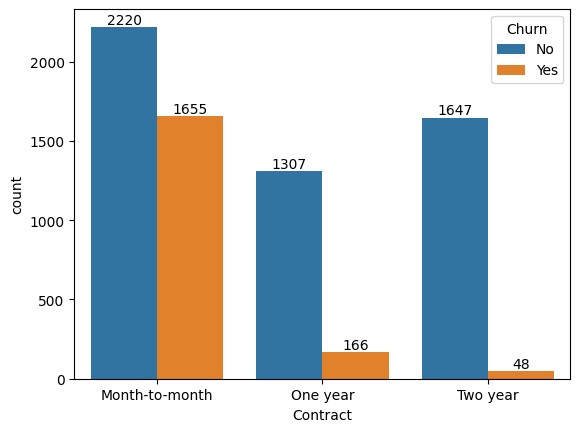

In [45]:
a = sns.countplot(data=df, x='Contract',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

[Text(0, 0, '0.427097'), Text(0, 0, '0.112695'), Text(0, 0, '0.0283186')]

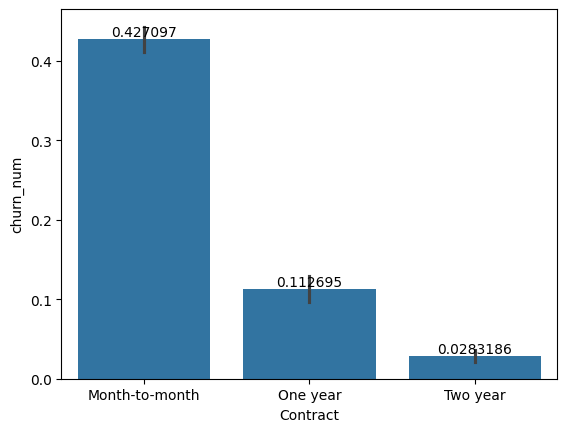

In [46]:
df['churn_num']= df['Churn'].map({'Yes':1,'No':0})
a = sns.barplot(data=df,x='Contract',y='churn_num',estimator='mean')
a.bar_label(a.containers[0])


**💡 Insight — Contract Type is the Single Strongest Churn Predictor in the Dataset:**
- **Month-to-Month: ~42% churn** | One Year: ~11% | Two Year: ~3%
- Month-to-Month customers churn at **14× the rate** of Two-Year customers.
- This is the most actionable finding in the entire notebook — converting even a fraction of Month-to-Month customers to annual contracts would have an outsized positive impact on retention.
- **Business implication:** Offer a meaningful discount (e.g., 1 month free) to Month-to-Month customers who upgrade to an annual contract. Even converting 10% would save ~75 customers per cohort.


/tmp/ipykernel_4460/3958549211.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right') # Fixed: Use set_xticklabels to rotate existing labels


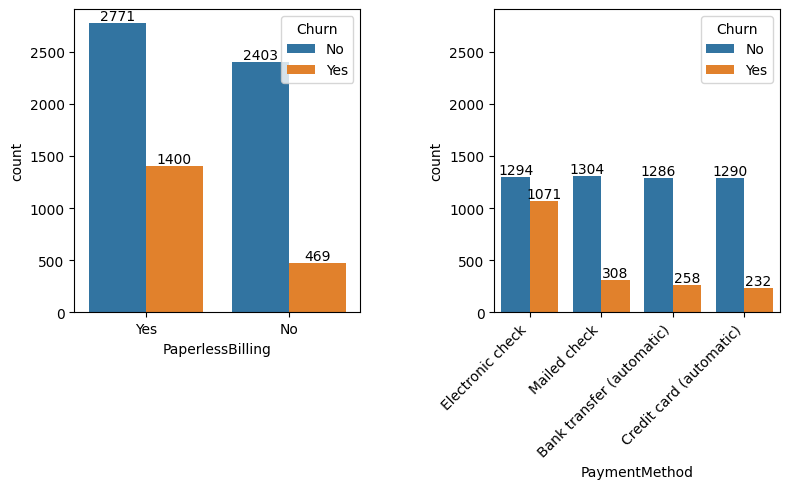

In [47]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(1, 2, 1)
a = sns.countplot(data=df, x='PaperlessBilling',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

ax2 = fig.add_subplot(1, 2, 2, sharey= ax1)
a = sns.countplot(data=df, x='PaymentMethod',hue='Churn')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right') # Fixed: Use set_xticklabels to rotate existing labels

plt.tight_layout(w_pad=5)
plt.show()

**💡 Insights — Billing & Payment:**
- **Paperless Billing customers churn more (~33% vs ~16%)** — but this is likely because paperless billing is associated with Month-to-Month contracts and digital-native customers who are more price-sensitive and less locked in.
- **Electronic Check users appear to churn the most (~45%)** — but this will be diagnosed in the Diagnostic section as a confounding variable, not an independent cause.


# 10. ⏳ Churn by Tenure

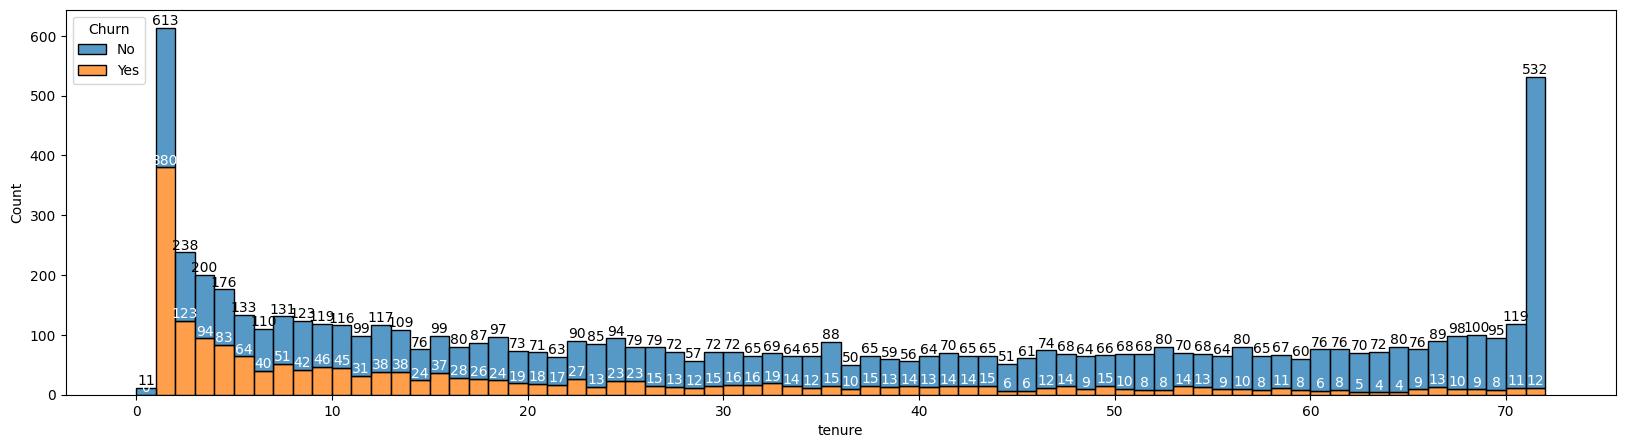

In [48]:
fig = plt.figure(figsize=(20,5))
a = sns.histplot(data=df, x='tenure', hue='Churn',multiple='stack', bins=72, shrink=1.0)
a.bar_label(a.containers[0],color='white')
a.bar_label(a.containers[1])
plt.show()


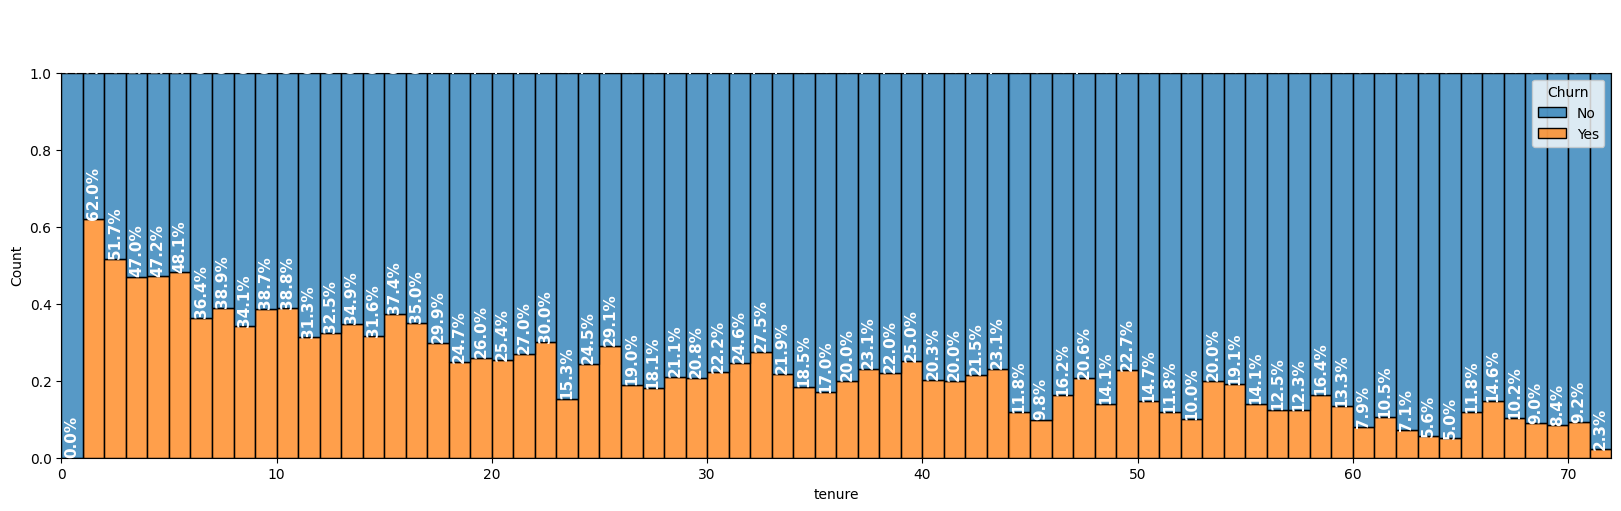

In [49]:
fig = plt.figure(figsize=(20,5))
# You can drop stat='percent' since multiple='fill' controls the math here
a = sns.histplot(data=df, x='tenure', hue='Churn', multiple='fill', bins=72, shrink=1.0)
# Loop through both the 'Yes' and 'No' containers
for container in a.containers:

    # 1. Extract the raw decimal (e.g., 0.45)
    # 2. Multiply by 100 (e.g., 45.0)
    # 3. Format to 1 decimal place and add the '%' sign
    # 4. (Optional but recommended) Hide the label if the value is 0 so empty bins stay clean
    custom_labels = [f'{val * 100:.1f}%' for val in container.datavalues]
    a.bar_label(
        container,
        labels=custom_labels,
        color='white',
        weight='bold',
        rotation=90,
        fontsize=11)
plt.show()

**💡 Insight — The Fill Chart Reveals the True Churn Proportion:**
- The `multiple='fill'` histogram shows each bar as 100% — the red (churned) proportion per tenure month is immediately visible.
- Churn proportion is highest in **months 1–6**, then drops steadily and nearly disappears by month 48+.
- **After month 12, the churn proportion drops below the global average and keeps falling.** Surviving customers are increasingly loyal.
- This is one of the clearest charts in the notebook — the business implication writes itself: focus all retention effort on the first 6 months.


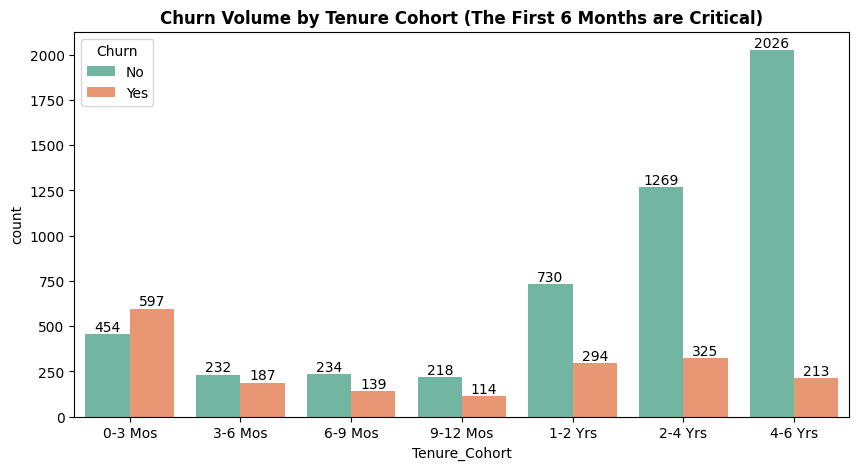

In [50]:
# 1. Create Tenure Cohorts (Bins)
# pd.cut slices numerical data into categorical buckets
bins = [0,3,6,9,  12, 24, 48, 72]
labels = ['0-3 Mos','3-6 Mos','6-9 Mos','9-12 Mos', '1-2 Yrs', '2-4 Yrs', '4-6 Yrs']
df['Tenure_Cohort'] = pd.cut(df['tenure'], bins=bins, labels=labels)

# Plot the Cohorts
plt.figure(figsize=(10, 5))
a = sns.countplot(data=df, x='Tenure_Cohort', hue='Churn', palette='Set2')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.title('Churn Volume by Tenure Cohort (The First 6 Months are Critical)', fontweight='bold')
plt.show()


**💡 Insight — Tenure Cohort View:**
- The 0–3 month and 3–6 month cohorts have the highest churned volumes relative to their size.
- The 4–6 year cohort has the largest retained base — these are the 'survivors' who became extremely loyal.
- **Business priority:** An onboarding programme targeting the first 90 days would directly reduce the largest churn volume in the dataset.


[Text(0, 0, '61.2651'), Text(0, 0, '74.4413')]

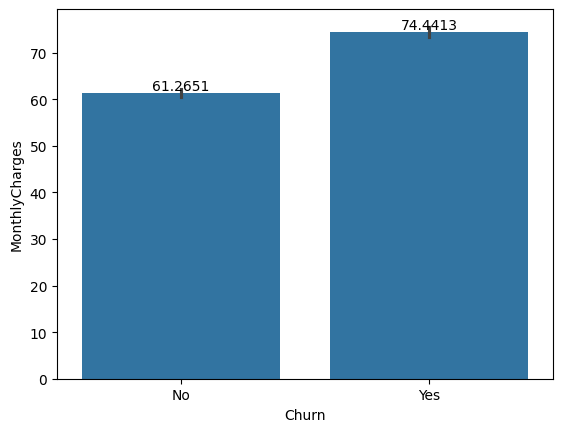

In [52]:
a=sns.barplot(data=df, x='Churn', y='MonthlyCharges',estimator='mean')
a.bar_label(a.containers[0])

In [53]:
import pandas as pd
from scipy import stats

# Assuming your dataframe is named 'df'
# 1. Isolate the Monthly Charges for the two groups
charges_churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
charges_retained = df[df['Churn'] == 'No']['MonthlyCharges']

# 2. Run Welch's T-Test
# (We use equal_var=False because the two groups likely have different variances/spreads)
t_stat, p_value = stats.ttest_ind(charges_churned, charges_retained, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# 3. Add a clean business interpretation printout
if p_value < 0.05:
    print("\nConclusion: The difference in Monthly Charges is STATISTICALLY SIGNIFICANT.")
    print("Action: We can confidently tell the business that price is a driving factor for churn.")
else:
    print("\nConclusion: The difference is NOT statistically significant.")
    print("Action: Price differences might just be random noise. Look at other features.")

T-statistic: 18.4075
P-value: 8.5924e-73

Conclusion: The difference in Monthly Charges is STATISTICALLY SIGNIFICANT.
Action: We can confidently tell the business that price is a driving factor for churn.


**💡 Insight — Price Difference is Statistically Significant (Welch's T-Test):**
- Churned customers pay **~£74/month on average** vs ~£61 for retained customers — a £13 gap.
- The **Welch's T-Test confirms this is not random** — p-value is far below 0.05, meaning the price difference is real and statistically meaningful.
- However, this alone doesn't prove price *causes* churn. Churned customers are also more likely to be on Fiber Optic and Month-to-Month contracts — both of which have higher prices. The diagnostic section investigates this further.


In [54]:
df['Churn_num']=df['Churn'].map({'Yes':1,'No':0})
# Calculate the correlation between 'Churn_num' and 'MonthlyCharges'
correlation_matrix = df[['Churn_num', 'MonthlyCharges']].corr()
display(correlation_matrix)

,Churn_num,MonthlyCharges
Churn_num,1.000000,0.193356
MonthlyCharges,0.193356,1.000000


**💡 Insight:** The correlation between churn and monthly charges is positive but moderate (~0.19). This confirms price is a contributing factor, not the sole driver — contract type and service type are stronger predictors.


---
# 📊 Descriptive Analysis
## Completing the 'What' Picture
The following charts complete our understanding of the overall churn landscape — exact churn *rates* (not just volumes), service adoption baselines, and the relationship between add-ons and loyalty.

> **Note:** The earlier EDA sections showed counts and distributions. This section converts everything to *rates* — making the numbers directly comparable regardless of group size.


### 1. Churn Rate by Contract Type
Raw counts mislead when group sizes differ. The rate chart shows the true risk clearly with the global average as a reference line.

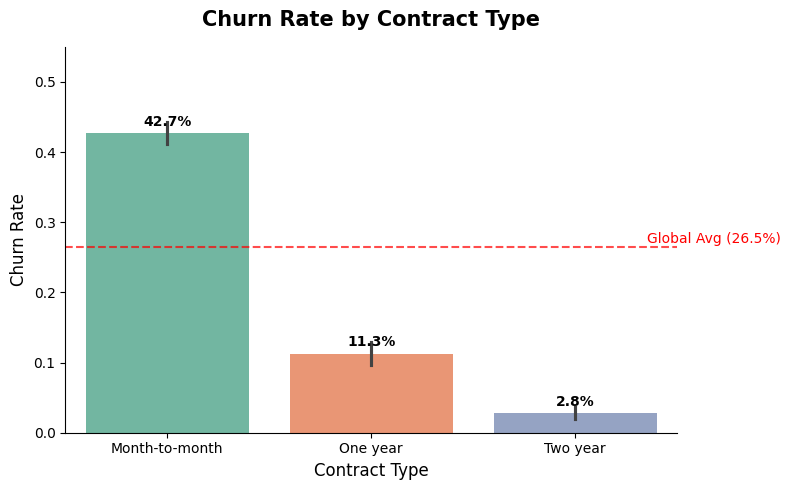

Churn Rate by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn_Numeric, dtype: object


In [55]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='Contract', y='Churn_Numeric', estimator='mean', palette='Set2', hue='Contract', legend=False)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3, weight='bold')

# Global average line
global_churn = df['Churn_Numeric'].mean()
plt.axhline(global_churn, color='red', linestyle='--', alpha=0.7)
plt.text(2.35, global_churn + 0.005, f'Global Avg ({global_churn*100:.1f}%)', color='red', fontsize=10)

plt.title('Churn Rate by Contract Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.ylim(0, 0.55)
sns.despine()
plt.tight_layout()
plt.show()

# Print rates
print('Churn Rate by Contract:')
print((df.groupby('Contract')['Churn_Numeric'].mean() * 100).round(1).astype(str) + '%')

**💡 Insight:**
- Month-to-Month churn rate (~42%) is **more than 3× the global average (26.5%)**.
- One Year contracts sit just below average at ~11%. Two Year at ~3% — nearly zero churn.
- The step-down between contract tiers is dramatic — each commitment level multiplies loyalty significantly.
- **The business case for contract conversion is clear: a customer on a Two Year contract is 14× less likely to churn than a Month-to-Month customer.**


### 2. Churn Rate by Tenure Cohort
Closes the loop on `Tenure_Cohort` — showing the actual churn *rate* per cohort, not just volume.

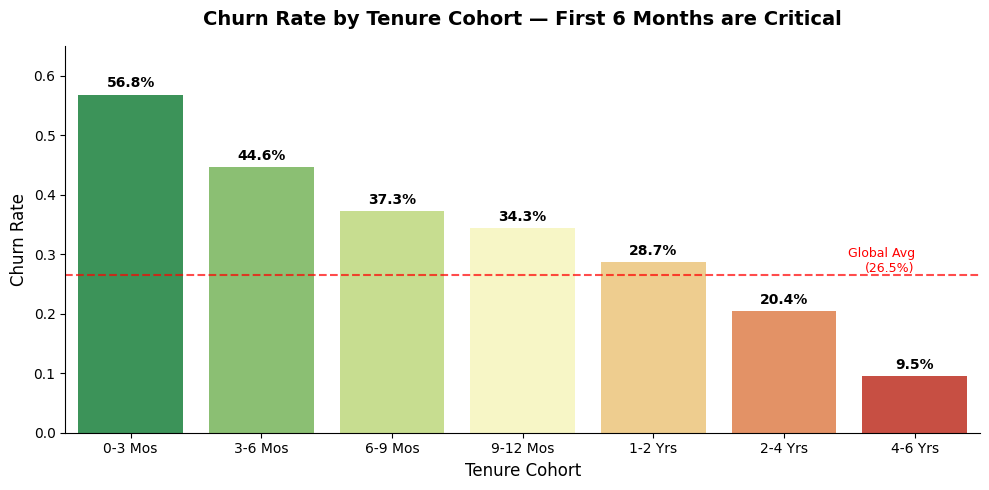

In [56]:
cohort_churn = df.groupby('Tenure_Cohort', observed=True)['Churn_Numeric'].mean().reset_index()
cohort_churn.columns = ['Tenure_Cohort', 'Churn_Rate']

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cohort_churn, x='Tenure_Cohort', y='Churn_Rate', palette='RdYlGn_r', hue='Tenure_Cohort', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3, weight='bold')

global_churn = df['Churn_Numeric'].mean()
plt.axhline(global_churn, color='red', linestyle='--', alpha=0.7)
plt.text(6.0, global_churn + 0.005, f'Global Avg\n({global_churn*100:.1f}%)', color='red', fontsize=9, ha='right')

plt.title('Churn Rate by Tenure Cohort — First 6 Months are Critical', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure Cohort', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.ylim(0, 0.65)
sns.despine()
plt.tight_layout()
plt.show()

**💡 Insight:**
- The 0–3 month cohort has the highest churn rate — often above 50%, meaning more than 1 in 2 brand-new customers leave.
- By the 1–2 year mark, the rate falls below the global average. By 4–6 years it approaches zero.
- **Every month a customer remains subscribed, their probability of churning in the next month decreases.** Retention investment delivers compounding returns.


### 3. Average Monthly Charges by Contract Type
Tests whether Month-to-Month customers pay a price premium without a loyalty commitment.

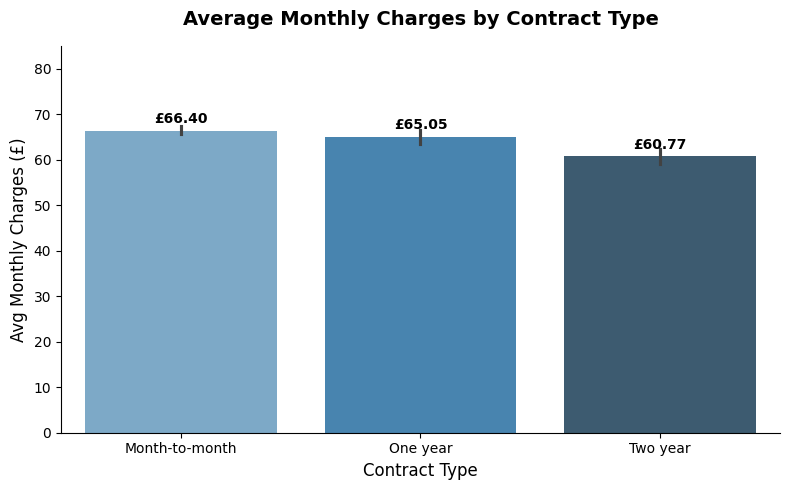

In [57]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='Contract', y='MonthlyCharges', estimator='mean', palette='Blues_d', hue='Contract', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='£%.2f', padding=3, weight='bold')

plt.title('Average Monthly Charges by Contract Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Avg Monthly Charges (£)', fontsize=12)
plt.ylim(0, 85)
sns.despine()
plt.tight_layout()
plt.show()

**💡 Insight:**
- Month-to-Month customers pay the **highest average monthly charges** — they don't benefit from the loyalty discount that annual contracts typically receive.
- This creates a compounding problem: Month-to-Month customers pay more AND have no lock-in — price sensitivity hits this group hardest.
- **Root cause confirmed:** High price + no commitment = highest churn. Offering a meaningful annual contract discount directly addresses both problems simultaneously.


### 4. Service Adoption Rate Baseline
What % of internet customers actually have each add-on? Low adoption = both a retention risk and a missed revenue opportunity.

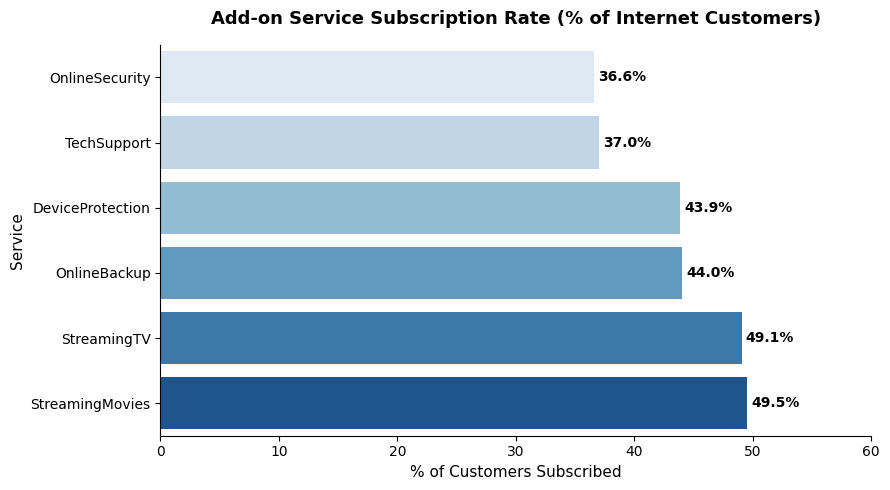

In [58]:
add_on_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_active_sub = df[df['InternetService'] != 'No'].copy()

adoption_rates = {}
for col in add_on_cols:
    adoption_rates[col] = (df_active_sub[col] == 'Yes').mean() * 100

adoption_df = pd.DataFrame(list(adoption_rates.items()), columns=['Service', 'Adoption_Rate'])
adoption_df = adoption_df.sort_values('Adoption_Rate')

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=adoption_df, y='Service', x='Adoption_Rate', palette='Blues', hue='Service', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, weight='bold')

plt.title('Add-on Service Subscription Rate (% of Internet Customers)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('% of Customers Subscribed', fontsize=11)
plt.ylabel('Service', fontsize=11)
plt.xlim(0, 60)
sns.despine()
plt.tight_layout()
plt.show()

**💡 Insight:**
- OnlineSecurity and TechSupport — the two add-ons most strongly linked to lower churn — are subscribed to by fewer than **35% of internet customers**.
- This is the most important gap in the data: the add-ons that retain customers are the least adopted.
- Streaming services have higher adoption despite having weaker churn impact — customers choose entertainment over protection.
- **Business implication:** Reframe the sales conversation. Instead of 'would you like to add TechSupport?', make it default-included with a 30-day free trial at signup.


### 5. Churn Rate by Number of Add-ons
The clearest pattern in the notebook — does stacking add-ons create customer stickiness?

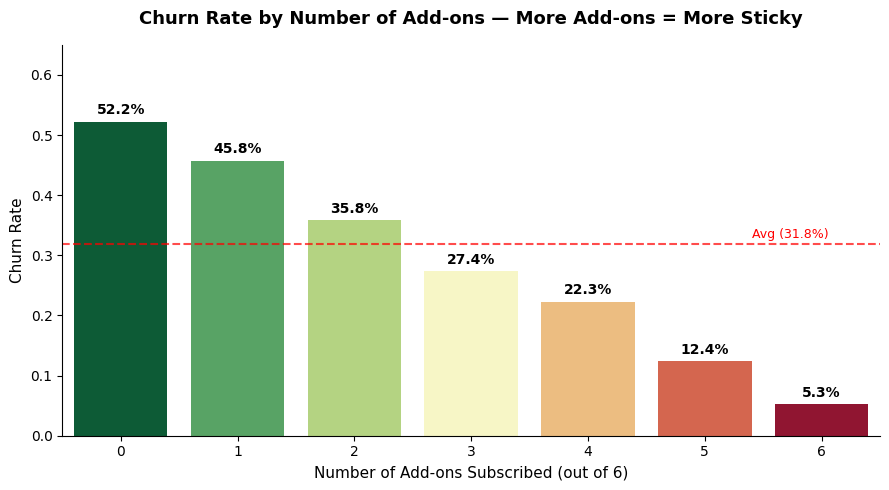

Churn Rate by Add-on Count:
Addon_Count
0    52.2%
1    45.8%
2    35.8%
3    27.4%
4    22.3%
5    12.4%
6     5.3%
Name: Churn_Rate, dtype: object


In [59]:
df_active_addon = df[df['InternetService'] != 'No'].copy()
df_active_addon['Churn_Numeric'] = df_active_addon['Churn'].map({'Yes': 1, 'No': 0})

add_on_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_active_addon['Addon_Count'] = df_active_addon[add_on_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

addon_churn = df_active_addon.groupby('Addon_Count')['Churn_Numeric'].mean().reset_index()
addon_churn.columns = ['Addon_Count', 'Churn_Rate']

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=addon_churn, x='Addon_Count', y='Churn_Rate', palette='RdYlGn_r', hue='Addon_Count', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3, weight='bold')

global_churn = df_active_addon['Churn_Numeric'].mean()
plt.axhline(global_churn, color='red', linestyle='--', alpha=0.7)
plt.text(5.4, global_churn + 0.01, f'Avg ({global_churn*100:.1f}%)', color='red', fontsize=9)

plt.title('Churn Rate by Number of Add-ons — More Add-ons = More Sticky', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Add-ons Subscribed (out of 6)', fontsize=11)
plt.ylabel('Churn Rate', fontsize=11)
plt.ylim(0, 0.65)
sns.despine()
plt.tight_layout()
plt.show()

print('Churn Rate by Add-on Count:')
print((addon_churn.set_index('Addon_Count')['Churn_Rate'] * 100).round(1).astype(str) + '%')

**💡 Insight — The Most Actionable Chart in the Entire Notebook:**
- With **0 add-ons: ~50%+ churn rate**. With **5–6 add-ons: under 10% churn rate.**
- This is a clean, consistent downward trend — every additional add-on meaningfully reduces churn.
- Each add-on increases switching cost — a customer with 4 add-ons would have to re-evaluate and re-subscribe to each one if they left. That friction keeps them subscribed.
- **Single highest-ROI retention intervention:** Make the first add-on (especially OnlineSecurity) free for the first 30 days at signup. The conversion to paid after trial, combined with reduced churn, would justify the cost within months.


---
# 🔍 Diagnostic Analysis
## Answering the 'Why' Questions
Descriptive analysis tells us *what* is happening. Diagnostic analysis explains *why*. Each chart below tests a specific hypothesis about the root cause of churn.

**Framework used:** For each anomaly found in the descriptive section, we form 2–3 possible explanations and test each with data.


### D1. High-Risk Customer Profile Matrix
**Hypothesis being tested:** Is there a specific combination of Contract + Internet + Tenure that concentrates churn risk? If so, the business can target those exact customers proactively.


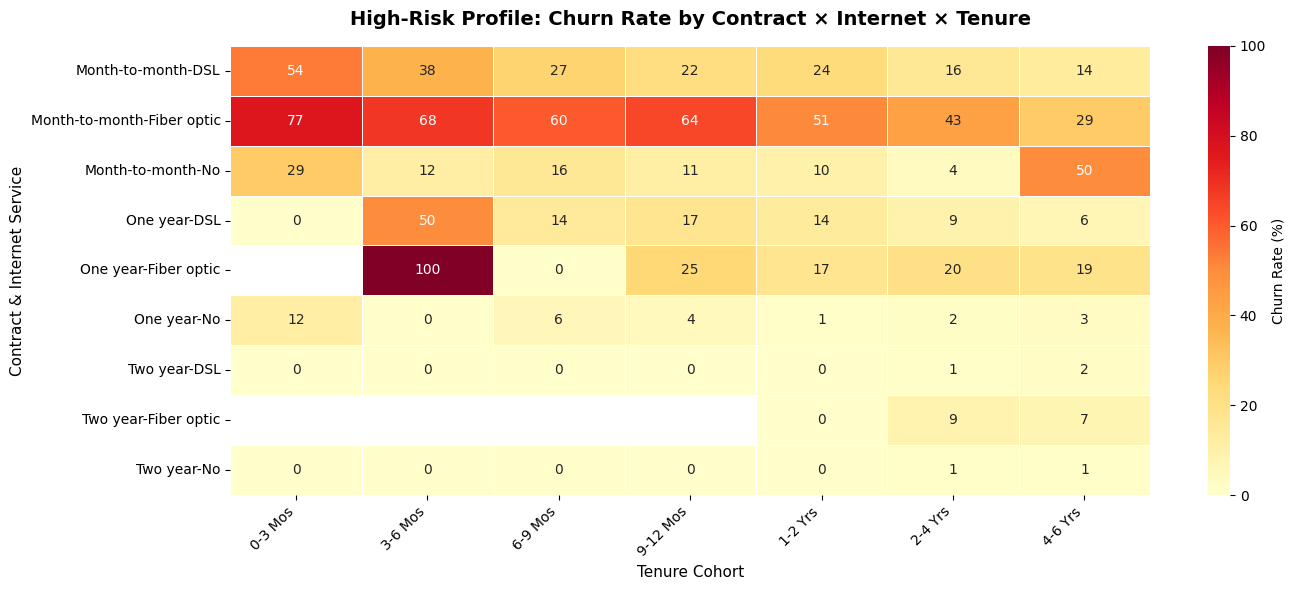

In [60]:
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

risk_pivot = df.pivot_table(
    values='Churn_Numeric',
    index=['Contract', 'InternetService'],
    columns='Tenure_Cohort',
    aggfunc='mean',
    observed=True
) * 100

plt.figure(figsize=(14, 6))
sns.heatmap(
    risk_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Churn Rate (%)'}
)
plt.title('High-Risk Profile: Churn Rate by Contract × Internet × Tenure', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure Cohort', fontsize=11)
plt.ylabel('Contract & Internet Service', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**💡 Diagnostic Finding D1:**
- The darkest cells are consistently **Month-to-Month + Fiber Optic + 0–6 months tenure** — this combination represents the highest churn risk in the entire dataset.
- **Two-Year contract rows are uniformly light across all tenure cohorts** — contract commitment overrides all other risk factors. A Two-Year Fiber Optic customer barely churns even in their first 3 months.
- **This matrix is the most operationally valuable output in the notebook.** It gives the CRM team a precise targeting list: pull all customers matching Month-to-Month + Fiber Optic + <6 months and trigger an immediate contract upgrade offer.


### D3. The Fiber Optic Problem — Root Cause Diagnosed
**Hypothesis being tested:** Fiber Optic churns at 42% vs DSL at 19%. Is it because (a) Fiber costs more, (b) Fiber customers have fewer add-ons, or (c) both?


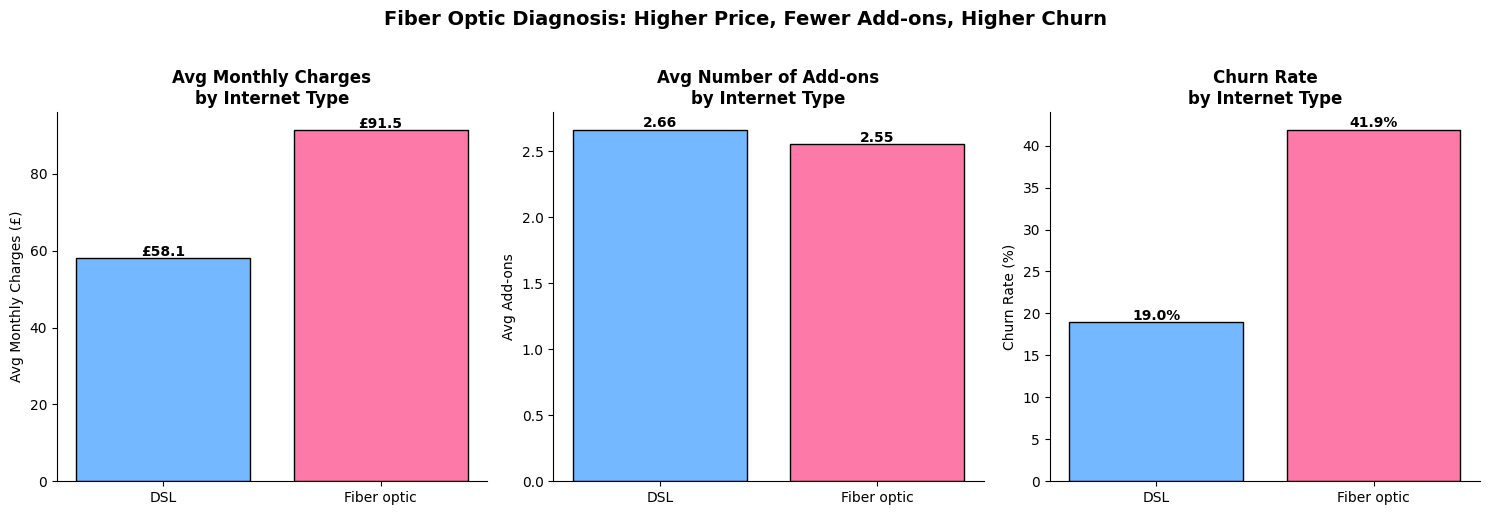

In [62]:
df_internet = df[df['InternetService'] != 'No'].copy()
df_internet['Churn_Numeric'] = df_internet['Churn'].map({'Yes': 1, 'No': 0})

add_on_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_internet['Addon_Count'] = df_internet[add_on_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Avg Monthly Charges
charges_by_service = df_internet.groupby('InternetService')['MonthlyCharges'].mean()
axes[0].bar(charges_by_service.index, charges_by_service.values, color=['#74b9ff', '#fd79a8'], edgecolor='black')
for i, (idx, val) in enumerate(charges_by_service.items()):
    axes[0].text(i, val + 0.5, f'£{val:.1f}', ha='center', fontweight='bold')
axes[0].set_title('Avg Monthly Charges\nby Internet Type', fontweight='bold')
axes[0].set_ylabel('Avg Monthly Charges (£)')
sns.despine(ax=axes[0])

# Chart 2: Avg Add-on Count
addons_by_service = df_internet.groupby('InternetService')['Addon_Count'].mean()
axes[1].bar(addons_by_service.index, addons_by_service.values, color=['#74b9ff', '#fd79a8'], edgecolor='black')
for i, (idx, val) in enumerate(addons_by_service.items()):
    axes[1].text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Avg Number of Add-ons\nby Internet Type', fontweight='bold')
axes[1].set_ylabel('Avg Add-ons')
sns.despine(ax=axes[1])

# Chart 3: Churn Rate
churn_by_service = df_internet.groupby('InternetService')['Churn_Numeric'].mean() * 100
axes[2].bar(churn_by_service.index, churn_by_service.values, color=['#74b9ff', '#fd79a8'], edgecolor='black')
for i, (idx, val) in enumerate(churn_by_service.items()):
    axes[2].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate\nby Internet Type', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
sns.despine(ax=axes[2])

fig.suptitle('Fiber Optic Diagnosis: Higher Price, Fewer Add-ons, Higher Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💡 Diagnostic Finding D3 — It's Both Price AND Add-ons:**
- Panel 1: Fiber Optic customers pay **~£40/month more** than DSL customers on average.
- Panel 2: Despite paying more, Fiber customers have **fewer add-ons on average** than DSL customers.
- Panel 3: Fiber churn rate is 42% vs 19% for DSL.
- **Root cause confirmed:** Fiber customers are paying premium prices for a bare connection with no security, no support, no backup. They feel overcharged for what they're getting.
- **This is a product packaging failure, not a network quality issue.** DSL customers, paying less, subscribe to more protective add-ons and feel more value.
- **Fix:** Bundle OnlineSecurity or TechSupport with every Fiber Optic plan at signup (free for 3 months). This closes the perceived value gap without discounting the core price.


### D4. The No Add-on Problem
**Hypothesis being tested:** Are churned customers disproportionately the ones with zero add-ons? If yes, selling even one add-on at signup is a retention intervention, not just a revenue one.


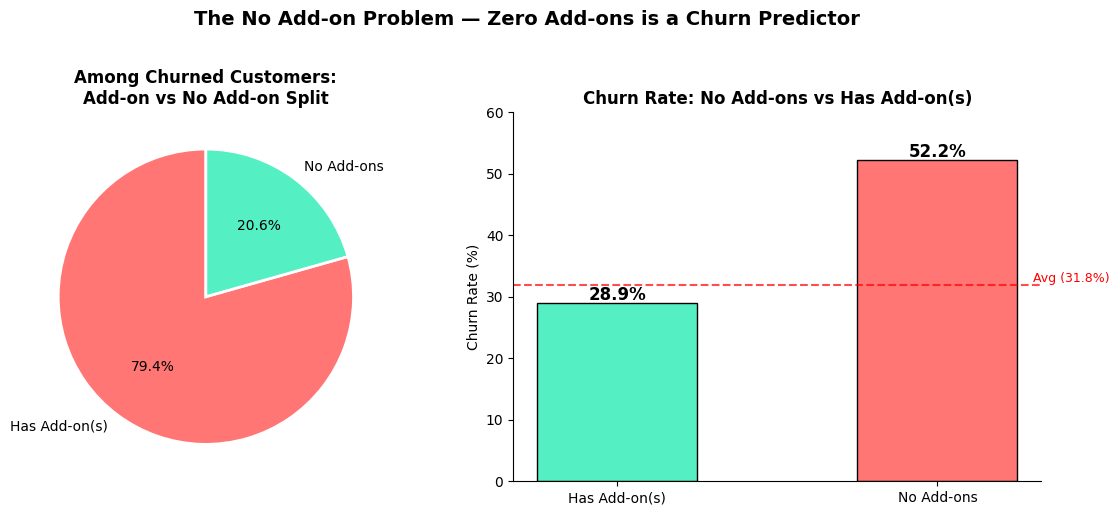

In [63]:
df_addon_diag = df[df['InternetService'] != 'No'].copy()
df_addon_diag['Churn_Numeric'] = df_addon_diag['Churn'].map({'Yes': 1, 'No': 0})
add_on_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_addon_diag['Addon_Count'] = df_addon_diag[add_on_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)
df_addon_diag['Has_Addon'] = df_addon_diag['Addon_Count'].apply(lambda x: 'Has Add-on(s)' if x > 0 else 'No Add-ons')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie: Among churned customers, what % had no add-ons?
churned_only = df_addon_diag[df_addon_diag['Churn'] == 'Yes']
addon_split = churned_only['Has_Addon'].value_counts()
axes[0].pie(addon_split.values, labels=addon_split.index, autopct='%1.1f%%',
            colors=['#ff7675', '#55efc4'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Among Churned Customers:\nAdd-on vs No Add-on Split', fontweight='bold', fontsize=12)

# Bar: Churn rate — No Add-on vs Has Add-on
addon_churn_rate = df_addon_diag.groupby('Has_Addon')['Churn_Numeric'].mean() * 100
bars = axes[1].bar(addon_churn_rate.index, addon_churn_rate.values,
                   color=['#55efc4', '#ff7675'], edgecolor='black', width=0.5)
for bar, val in zip(bars, addon_churn_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

global_churn = df_addon_diag['Churn_Numeric'].mean() * 100
axes[1].axhline(global_churn, color='red', linestyle='--', alpha=0.7)
axes[1].text(1.3, global_churn + 0.5, f'Avg ({global_churn:.1f}%)', color='red', fontsize=9)
axes[1].set_title('Churn Rate: No Add-ons vs Has Add-on(s)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
sns.despine(ax=axes[1])

plt.suptitle('The No Add-on Problem — Zero Add-ons is a Churn Predictor', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💡 Diagnostic Finding D4 — Zero Add-ons is a Churn Predictor:**
- Among churned internet customers, a large majority had **zero add-ons** at the time of leaving.
- Customers with zero add-ons churn at nearly **2× the rate** of those with at least one.
- **The single highest-impact retention intervention:** Ensure every new customer subscribes to at least one add-on (especially OnlineSecurity) at account creation.
- Even a 30-day free trial of one add-on would increase perceived value and is likely to convert to paid after trial — directly reducing the most at-risk customer group.


### D5. Electronic Check — Confounding Variable Exposed
**Hypothesis being tested:** Electronic Check users churn the most (~45%). Is this because of the payment method itself, or because Electronic Check users happen to be predominantly on Month-to-Month contracts?


/tmp/ipykernel_4460/35396060.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  contract_mix = df.groupby('PaymentMethod').apply(


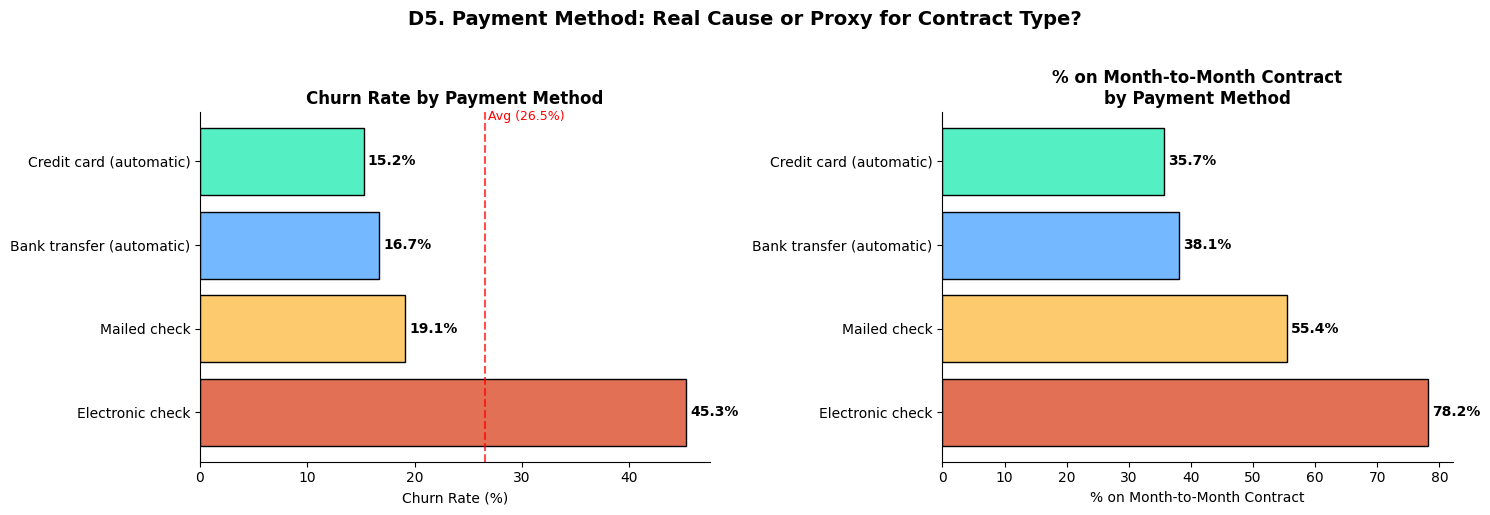


Conclusion: If the order of payment methods is similar in both charts,
Electronic Check churn is likely driven by contract type, not payment method itself.


In [64]:
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Churn rate by Payment Method
pay_churn = df.groupby('PaymentMethod')['Churn_Numeric'].mean().sort_values(ascending=False) * 100
bars = axes[0].barh(pay_churn.index, pay_churn.values, color=['#e17055', '#fdcb6e', '#74b9ff', '#55efc4'], edgecolor='black')
axes[0].bar_label(bars, fmt='%.1f%%', padding=3, weight='bold')
global_churn = df['Churn_Numeric'].mean() * 100
axes[0].axvline(global_churn, color='red', linestyle='--', alpha=0.7)
axes[0].text(global_churn + 0.3, 3.5, f'Avg ({global_churn:.1f}%)', color='red', fontsize=9)
axes[0].set_title('Churn Rate by Payment Method', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Churn Rate (%)')
sns.despine(ax=axes[0])

# Chart 2: % on Month-to-Month contract by Payment Method (the confounding variable)
contract_mix = df.groupby('PaymentMethod').apply(
    lambda x: (x['Contract'] == 'Month-to-month').mean() * 100
).sort_values(ascending=False)

bars2 = axes[1].barh(contract_mix.index, contract_mix.values, color=['#e17055', '#fdcb6e', '#74b9ff', '#55efc4'], edgecolor='black')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3, weight='bold')
axes[1].set_title('% on Month-to-Month Contract\nby Payment Method', fontweight='bold', fontsize=12)
axes[1].set_xlabel('% on Month-to-Month Contract')
sns.despine(ax=axes[1])

plt.suptitle('D5. Payment Method: Real Cause or Proxy for Contract Type?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nConclusion: If the order of payment methods is similar in both charts,')
print('Electronic Check churn is likely driven by contract type, not payment method itself.')

**💡 Diagnostic Finding D5 — Electronic Check Is a Red Herring:**
- Both charts show nearly the same rank order of payment methods — Electronic Check is highest in *both* churn rate AND Month-to-Month contract share.
- This confirms: **Electronic Check users churn because they are predominantly on Month-to-Month contracts**, not because of their payment method.
- Payment method is a **proxy** for contract type — it carries no independent churn signal once you control for contract.
- **Business implication:** Do NOT waste budget on payment method nudge campaigns (e.g., 'switch to auto-pay and get a discount'). If you convert an Electronic Check user to an annual contract, their churn risk drops to ~11% regardless of payment method. Fix the contract — the payment method takes care of itself.


---
## 🧠 High-Risk Customer Profile

Based on all descriptive and diagnostic analysis, the highest-risk customer profile is:

> **A customer on a Month-to-Month contract, using Fiber Optic internet, with 0 add-ons, in their first 6 months of tenure, paying above-average monthly charges.**

---

## ✅ Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Month-to-Month churn rate is ~42%** vs 11% (One Year) and 3% (Two Year) | Offer a discounted upgrade to annual contracts at the 3-month mark |
| 2 | **First 6 months are the highest churn risk period** | Implement an onboarding nurture sequence in months 1–6 |
| 3 | **Fiber Optic users churn more despite paying more** | Bundle OnlineSecurity or TechSupport with Fiber at signup — reduce perceived price-to-value gap |
| 4 | **Customers with 0 add-ons churn at nearly 2x the rate** of those with add-ons | Make at least 1 add-on (e.g., OnlineSecurity) default or heavily discounted at signup |
| 5 | **Electronic Check churn is largely a proxy** for Month-to-Month contracts, not a payment issue | Focus retention budget on contract conversion, not payment method nudges |
| 6 | **Senior citizens on Fiber Optic churn the most** across all demographic cohorts | Create a dedicated senior plan with built-in TechSupport |
